# 🛡️ Skripsi: Perbandingan Kinerja RoBERTa-base dan DistilBERT-base untuk Deteksi Phishing URL

**Notebook Eksperimen & Pipeline Pelatihan Deep Learning**  
- **Target Runtime**: Google Colab (GPU NVIDIA Tesla T4 16GB / CUDA)  
- **Storage Backend**: Google Drive (`/content/drive/MyDrive/Skripsi/`) untuk persistensi data & model  
- **Arsitektur Model**: RoBERTa-base (BPE) vs DistilBERT-base (WordPiece)  
- **Objektif Pipeline**: Setup Google Drive, preprocessing, tokenisasi, fine-tuning teroptimasi GPU T4, pelacakan efisiensi komputasi, evaluasi independen test set, visualisasi komparatif, dan ekspor hasil.

## 0. Setup Google Drive Mounting & Verifikasi Hardware GPU
Menghubungkan Google Drive untuk persistensi penyimpanan dataset, checkpoint model, dan hasil evaluasi, serta mengecek ketersediaan GPU NVIDIA (Tesla T4 16GB).

In [1]:
# 1. Mount Google Drive dengan error handling aman
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("[OK] Google Drive berhasil di-mount di /content/drive")
except Exception as e:
    print(f"[INFO] Menjalankan di luar Google Colab atau Drive sudah ter-mount: {e}")

# 2. Verifikasi GPU dan CUDA Environment
try:
    get_ipython().system('nvidia-smi')
except Exception:
    pass

import torch
print(f"\nPyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name     : {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM      : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
else:
    print("[WARN] GPU tidak terdeteksi. Jika di Colab, aktifkan via: Runtime > Change runtime type > T4 GPU.")

Mounted at /content/drive
[OK] Google Drive berhasil di-mount di /content/drive
Fri Sep 11 17:08:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                 

## 1. Instalasi Library & Dependensi
Menginstal seluruh paket yang dibutuhkan untuk modeling Transformer, akselerasi, evaluasi metrik, visualisasi, dan otomasi dataset.

In [2]:
# Instalasi dependensi
!pip install -q transformers accelerate evaluate pynvml scikit-learn pandas numpy kaggle datasets matplotlib seaborn

print("[OK] Semua library berhasil diinstal.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.3 MB/s eta 0:00:00
[OK] Semua library berhasil diinstal.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Inisialisasi Path & Pembuatan Struktur Folder di Google Drive
Mendefinisikan base directory pada Google Drive dan membuat struktur folder otomatis via `os.makedirs`:
- Base Folder: `/content/drive/MyDrive/Skripsi`
- Data Folder: `/content/drive/MyDrive/Skripsi/data/`
- Model RoBERTa: `/content/drive/MyDrive/Skripsi/models/RoBERTa_FineTuned/`
- Model DistilBERT: `/content/drive/MyDrive/Skripsi/models/DistilBERT_FineTuned/`
- Results: `/content/drive/MyDrive/Skripsi/results/`

In [4]:
import os

# Deteksi Path Utama di Google Drive dengan Fallback Dinamis
if os.path.exists("/content/drive/MyDrive"):
    BASE_DIR = "/content/drive/MyDrive/Skripsi"
elif os.path.exists("/content/drive/My Drive"):
    BASE_DIR = "/content/drive/My Drive/Skripsi"
elif os.path.exists("F:\\1. skripsi\\CODE"):
    BASE_DIR = "./"
    print(f"[INFO] Menjalankan di lingkungan lokal Windows. BASE_DIR: {os.path.abspath(BASE_DIR)}")
else:
    BASE_DIR = "./Skripsi"

print(f"[INFO] Target Base Directory: {os.path.abspath(BASE_DIR)}")

DATA_DIR = os.path.join(BASE_DIR, "data")
MODELS_DIR = os.path.join(BASE_DIR, "models")
ROBERTA_MODEL_DIR = os.path.join(MODELS_DIR, "RoBERTa_FineTuned")
ROBERTA_CKPT_DIR = os.path.join(MODELS_DIR, "RoBERTa_Checkpoints")
DISTILBERT_MODEL_DIR = os.path.join(MODELS_DIR, "DistilBERT_FineTuned")
DISTILBERT_CKPT_DIR = os.path.join(MODELS_DIR, "DistilBERT_Checkpoints")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

ALL_DIRS = [
    DATA_DIR,
    ROBERTA_MODEL_DIR,
    ROBERTA_CKPT_DIR,
    DISTILBERT_MODEL_DIR,
    DISTILBERT_CKPT_DIR,
    RESULTS_DIR
]

# Buat seluruh folder dan bersihkan konflik jika ada file bernama sama
for directory in ALL_DIRS:
    if os.path.exists(directory) and not os.path.isdir(directory):
        try:
            os.remove(directory)
            print(f"[CLEANED] File duplikat non-folder dihapus: {directory}")
        except Exception as e:
            print(f"[WARN] Tidak dapat menghapus {directory}: {e}")
    os.makedirs(directory, exist_ok=True)
    print(f"[DIR READY] {directory}")

print("\n[OK] Seluruh struktur direktori siap digunakan.")

[INFO] Target Base Directory: /content/drive/MyDrive/Skripsi
[DIR READY] /content/drive/MyDrive/Skripsi/data
[DIR READY] /content/drive/MyDrive/Skripsi/models/RoBERTa_FineTuned
[DIR READY] /content/drive/MyDrive/Skripsi/models/RoBERTa_Checkpoints
[DIR READY] /content/drive/MyDrive/Skripsi/models/DistilBERT_FineTuned
[DIR READY] /content/drive/MyDrive/Skripsi/models/DistilBERT_Checkpoints
[DIR READY] /content/drive/MyDrive/Skripsi/results

[OK] Seluruh struktur direktori siap digunakan.


## 3. Otomasi Kaggle: Konfigurasi Kredensial Google Drive & Unduh Dataset
Dataset: `moutasmtamimi/malicious-url-detection-dataset-enhanced-2026`

Langkah:
1. Menyalin kredensial `kaggle.json` dari Google Drive (`/content/drive/MyDrive/Skripsi/kaggle.json`) ke folder `~/.kaggle/` dan mengatur permission `chmod 600`.
2. Mengunduh dataset via Kaggle API.
3. Mengekstrak file dataset langsung ke folder data Google Drive (`/content/drive/MyDrive/Skripsi/data/`).

In [5]:
import os
import shutil
import zipfile
from pathlib import Path

# 1. Setup direktori ~/.kaggle dan Environment Variable
kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)
os.environ["KAGGLE_CONFIG_DIR"] = str(kaggle_dir)
target_kaggle_json = kaggle_dir / "kaggle.json"

# Deteksi lokasi kaggle.json dari Google Drive, lokal, atau upload
drive_kaggle_json = Path(BASE_DIR) / "kaggle.json"
possible_locations = [
    drive_kaggle_json,
    Path(r"F:\1. skripsi\CODE\kaggle.json"),
    Path("/content/kaggle.json"),
    Path("./kaggle.json"),
    Path("../kaggle.json"),
    target_kaggle_json
]

found_source = None
for loc in possible_locations:
    if loc.exists() and loc != target_kaggle_json:
        shutil.copy(loc, target_kaggle_json)
        found_source = loc
        print(f"[INFO] Menggunakan kaggle.json dari: {loc}")
        break

if target_kaggle_json.exists():
    try:
        os.chmod(target_kaggle_json, 0o600)
    except Exception as e:
        pass
    print(f"[OK] kaggle.json aktif di {target_kaggle_json} (Permission: 600)")
else:
    print("[WARN] kaggle.json belum ditemukan di Google Drive. Mengunggah secara interaktif di Colab:")
    try:
        from google.colab import files
        uploaded = files.upload()
        for fn in uploaded.keys():
            if fn == "kaggle.json":
                shutil.move(fn, str(target_kaggle_json))
                try:
                    shutil.copy(target_kaggle_json, drive_kaggle_json)
                except Exception:
                    pass
                os.chmod(target_kaggle_json, 0o600)
                print(f"[OK] kaggle.json berhasil diunggah dan disimpan di Google Drive: {drive_kaggle_json}")
    except ImportError:
        print(f"[ERROR] Tidak berada di Colab. Pastikan file kaggle.json berada di {drive_kaggle_json} atau di folder kerja.")

# 2. Download dan Ekstrak Dataset via Kaggle API CLI / Python API langsung ke DATA_DIR Google Drive
DATASET_SLUG = "moutasmtamimi/malicious-url-detection-dataset-enhanced-2026"
print(f"\n[DOWNLOADING] Mengunduh dataset {DATASET_SLUG} ke {DATA_DIR}...")

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(DATASET_SLUG, path=DATA_DIR, unzip=True)
    print("[OK] Dataset berhasil diunduh dan diekstrak via Kaggle Python API.")
except Exception as e:
    print(f"[INFO] Fallback ke Kaggle CLI karena: {e}")
    os.system(f'kaggle datasets download -d {DATASET_SLUG} -p "{DATA_DIR}" --unzip')

# Fallback unzipping jika ada file zip yang belum diekstrak
for f in os.listdir(DATA_DIR):
    if f.endswith(".zip"):
        zip_path = os.path.join(DATA_DIR, f)
        print(f"[UNZIPPING] Mengekstrak arsip zip: {zip_path}")
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(DATA_DIR)
        except Exception as ze:
            print(f"[WARN] Zip extraction note: {ze}")

print(f"\n[INFO] Daftar file di dalam {DATA_DIR}:")
for f in os.listdir(DATA_DIR):
    file_path = os.path.join(DATA_DIR, f)
    if os.path.isfile(file_path):
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"  - {f} ({size_mb:.2f} MB)")

[INFO] Menggunakan kaggle.json dari: /content/drive/MyDrive/Skripsi/kaggle.json
[OK] kaggle.json aktif di /root/.kaggle/kaggle.json (Permission: 600)

[DOWNLOADING] Mengunduh dataset moutasmtamimi/malicious-url-detection-dataset-enhanced-2026 ke /content/drive/MyDrive/Skripsi/data...
Dataset URL: https://www.kaggle.com/datasets/moutasmtamimi/malicious-url-detection-dataset-enhanced-2026
[OK] Dataset berhasil diunduh dan diekstrak via Kaggle Python API.

[INFO] Daftar file di dalam /content/drive/MyDrive/Skripsi/data:
  - MUD_malicious_urls_2026_V2.csv (360.36 MB)
  - dataset_with_all_features v2.csv (165.02 MB)
  - final_dataset_with_all_features.csv (119.94 MB)
  - final_dataset_with_all_features_v3.1.csv (144.40 MB)
  - train.csv (22.76 MB)
  - test.csv (4.87 MB)
  - val.csv (4.89 MB)


## 4. Pemuatan Data (Data Loading) dari Google Drive & Eksplorasi Awal
Memuat file CSV dataset (`dataset_with_all_features v2.csv`) dari direktori Google Drive ke dalam Pandas DataFrame.

In [6]:
import pandas as pd
import numpy as np
import glob

# 1. Pencarian file CSV dataset di Google Drive secara rekursif
target_csv = os.path.join(DATA_DIR, "dataset_with_all_features v2.csv")

if not os.path.exists(target_csv):
    csv_candidates = glob.glob(os.path.join(DATA_DIR, "**/*.csv"), recursive=True)
    valid_candidates = [c for c in csv_candidates if os.path.basename(c) not in ['train.csv', 'val.csv', 'test.csv']]
    
    if valid_candidates:
        target_csv = max(valid_candidates, key=os.path.getsize)
        print(f"[INFO] File dataset utama terdeteksi: {target_csv}")
    else:
        raise FileNotFoundError(f"File CSV dataset tidak ditemukan di {DATA_DIR}! Pastikan Cell 3 berhasil mengunduh dataset.")
else:
    print(f"[INFO] Memuat file target dari Google Drive: {target_csv}")

# 2. Memuat dataset ke Pandas DataFrame dengan low_memory=False
df_raw = pd.read_csv(target_csv, low_memory=False)
print(f"[RAW DATASET SHAPE] Baris: {df_raw.shape[0]:,}, Kolom: {df_raw.shape[1]}")
print("\nContoh 5 data teratas:")
display(df_raw.head())

print(f"\nTotal Kolom ({len(df_raw.columns)} kolom):")
print(df_raw.columns.tolist()[:15], "... (truncated)")

[INFO] Memuat file target dari Google Drive: /content/drive/MyDrive/Skripsi/data/dataset_with_all_features v2.csv
[RAW DATASET SHAPE] Baris: 651,191, Kolom: 68

Contoh 5 data teratas:


,url,type,label,web_is_live,web_security_score,web_forms_count,web_password_fields,web_has_login,web_ssl_valid,url_len,...,adv_domain_ngram_entropy,adv_path_entropy,adv_consonant_ratio,adv_vowel_ratio,adv_digit_ratio,adv_subdomain_count,adv_avg_subdomain_len,adv_token_count,adv_avg_token_length,Date_inspection
0,br-icloud.com.br,phishing,2.0,1,0,0,0,0,1,16,...,0.000000,3.375000,0.000000,0.000000,0.000000,0,0.0,4,3.250000,2026-02-15
1,mp3raid.com/music/krizz_kaliko.html,benign,0.0,0,0,0,0,0,1,35,...,0.000000,4.079143,0.000000,0.000000,0.028571,0,0.0,8,3.750000,2026-02-15
2,bopsecrets.org/rexroth/cr/1.htm,benign,0.0,1,0,0,0,0,1,31,...,0.000000,3.708093,0.000000,0.000000,0.032258,0,0.0,6,4.333333,2026-02-15
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1.0,1,0,0,0,0,1,84,...,4.000000,3.121928,0.533333,0.466667,0.083333,0,0.0,17,3.941176,2026-02-15
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1.0,1,0,0,0,0,1,235,...,4.459432,3.121928,0.523810,0.476190,0.093617,0,0.0,50,4.420000,2026-02-15



Total Kolom (68 kolom):
['url', 'type', 'label', 'web_is_live', 'web_security_score', 'web_forms_count', 'web_password_fields', 'web_has_login', 'web_ssl_valid', 'url_len', '@', '?', '-', '=', '.'] ... (truncated)


## 5. Preprocessing & Filtering Kelas (Benign vs Phishing)
Langkah pembersihan data:
1. Deteksi kolom URL dan Label/Type secara otomatis (bebas duplikasi nama kolom).
2. Menghapus missing values (`NaN`) dan URL duplikat.
3. Memfilter hanya menyisakan kelas **Benign** dan **Phishing**.
4. Melakukan mapping label biner: `{'Benign': 0, 'Phishing': 1}`.

In [7]:
# 1. Deteksi Kolom URL dan Label secara cerdas (mencegah error duplikasi nama kolom)
url_col = None
label_col = None

# Prioritas pencarian kolom URL
for candidate in ['url', 'urls', 'url_address', 'link', 'domain', 'web_url']:
    for c in df_raw.columns:
        if c.strip().lower() == candidate:
            url_col = c
            break
    if url_col:
        break

if not url_col:
    for c in df_raw.columns:
        if 'url' in c.strip().lower():
            url_col = c
            break
if not url_col:
    url_col = df_raw.columns[0]

# Prioritas pencarian kolom Label / Type
for candidate in ['type', 'label', 'class', 'category', 'target', 'result', 'status']:
    for c in df_raw.columns:
        if c.strip().lower() == candidate and c != url_col:
            label_col = c
            break
    if label_col:
        break

if not label_col:
    for c in df_raw.columns:
        if c != url_col:
            sample_vals = df_raw[c].dropna().astype(str).str.lower().unique()
            if any('benign' in str(v) or 'phish' in str(v) for v in sample_vals):
                label_col = c
                break

if not label_col:
    label_col = df_raw.columns[-1]

print(f"[COLUMN DETECTED] Kolom URL: '{url_col}' | Kolom Label: '{label_col}'")

# 2. Ekstraksi Series tunggal untuk membentuk DataFrame bersih bebas duplikasi
df = pd.DataFrame({
    'url': df_raw[url_col].copy(),
    'label': df_raw[label_col].copy()
})

# 3. Pembersihan Data
initial_len = len(df)
df['url'] = df['url'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip()

# Hapus baris kosong / NaN
df = df.dropna(subset=['url', 'label'])
df = df[(df['url'] != '') & (df['url'].str.lower() != 'nan')]

# Hapus duplikasi URL
df = df.drop_duplicates(subset=['url'])
print(f"[CLEANING] Data awal: {initial_len:,} | Setelah drop NA & Duplikat: {len(df):,}")

# 4. Eksplorasi Nilai Label Asli Sebelum Filtering
print("\n[DISTRIBUSI LABEL ASLI SEBELUM FILTERING]:")
print(df['label'].value_counts())

# 5. Filtering Kelas: Hanya Benign dan Phishing (Case-insensitive matching)
label_map_standard = {
    'benign': 'Benign',
    'safe': 'Benign',
    'legitimate': 'Benign',
    'good': 'Benign',
    '0': 'Benign',
    '0.0': 'Benign',
    'phishing': 'Phishing',
    'phish': 'Phishing',
    'bad': 'Phishing',
    'malicious': 'Phishing',
    '1': 'Phishing',
    '1.0': 'Phishing'
}

df['label_clean'] = df['label'].str.lower().map(label_map_standard)

# Sisakan hanya Benign dan Phishing (mengeliminasi defacement/malware jika ada)
df_filtered = df.dropna(subset=['label_clean']).copy()
df_filtered['label'] = df_filtered['label_clean']
df_filtered = df_filtered[['url', 'label']].reset_index(drop=True)

# Mapping Numerik Biner: Benign -> 0, Phishing -> 1
BINARY_LABEL_MAP = {'Benign': 0, 'Phishing': 1}
df_filtered['target'] = df_filtered['label'].map(BINARY_LABEL_MAP).astype(int)

print(f"\n[FILTERED DATASET SHAPE] Total Data Benign & Phishing: {len(df_filtered):,}")

# 6. Ringkasan Distribusi Kelas Final
print("\n[DISTRIBUSI KELAS FINAL]:")
dist_series = df_filtered['label'].value_counts()
dist_df = pd.DataFrame({
    'Kelas': dist_series.index,
    'Jumlah': dist_series.values,
    'Persentase (%)': (dist_series.values / len(df_filtered) * 100).round(2),
    'Target ID': [BINARY_LABEL_MAP[k] for k in dist_series.index]
})
display(dist_df)

print("\nContoh 5 data terproses:")
display(df_filtered.head(5))

[COLUMN DETECTED] Kolom URL: 'url' | Kolom Label: 'type'
[CLEANING] Data awal: 651,191 | Setelah drop NA & Duplikat: 640,081

[DISTRIBUSI LABEL ASLI SEBELUM FILTERING]:
label
benign        428156
defacement     95308
phishing       92909
malware        23636
nan               72
Name: count, dtype: int64

[FILTERED DATASET SHAPE] Total Data Benign & Phishing: 521,065

[DISTRIBUSI KELAS FINAL]:


,Kelas,Jumlah,Persentase (%),Target ID
0,Benign,428156,82.17,0
1,Phishing,92909,17.83,1



Contoh 5 data terproses:


,url,label,target
0,br-icloud.com.br,Phishing,1
1,mp3raid.com/music/krizz_kaliko.html,Benign,0
2,bopsecrets.org/rexroth/cr/1.htm,Benign,0
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,Benign,0
4,espn.go.com/nba/player/_/id/3457/brandon-rush,Benign,0


## 6. Pembagian Data Bertingkat & Simpan ke Google Drive (70% Train, 15% Val, 15% Test)
Menjaga proporsi kelas yang seimbang antara Benign dan Phishing di setiap subset data:
- **Train Set**: 70%
- **Validation Set**: 15%
- **Test Set**: 15%
- `random_state = 42` untuk *reproducibility* hasil riset.
- File disimpan langsung ke Google Drive: `/content/drive/MyDrive/Skripsi/data/`.

In [8]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Split 1: 70% Train, 30% Temp (Val + Test)
train_df, temp_df = train_test_split(
    df_filtered,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=df_filtered['target']
)

# Split 2: 50% dari 30% = 15% Validation, 15% Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df['target']
)

# Reset Index secara bersih
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Simpan hasil split ke Google Drive CSV
train_csv_path = os.path.join(DATA_DIR, "train.csv")
val_csv_path = os.path.join(DATA_DIR, "val.csv")
test_csv_path = os.path.join(DATA_DIR, "test.csv")

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print("[OK] File split berhasil disimpan ke Google Drive:")
print(f"  - Train CSV : {train_csv_path} ({len(train_df):,} baris)")
print(f"  - Val CSV   : {val_csv_path} ({len(val_df):,} baris)")
print(f"  - Test CSV  : {test_csv_path} ({len(test_df):,} baris)")

[OK] File split berhasil disimpan ke Google Drive:
  - Train CSV : /content/drive/MyDrive/Skripsi/data/train.csv (364,745 baris)
  - Val CSV   : /content/drive/MyDrive/Skripsi/data/val.csv (78,160 baris)
  - Test CSV  : /content/drive/MyDrive/Skripsi/data/test.csv (78,160 baris)


## 7. Validasi Distribusi Split & Ringkasan Metrik Awal
Memastikan tidak terjadi *data leakage* dan rasio kelas antar subset identik.

In [9]:
# Analisis Distribusi
split_summary = []

for name, subset in [("Train (70%)", train_df), ("Validation (15%)", val_df), ("Test (15%)", test_df)]:
    counts = subset['label'].value_counts()
    benign_cnt = counts.get('Benign', 0)
    phishing_cnt = counts.get('Phishing', 0)
    total = len(subset)
    split_summary.append({
        'Subset': name,
        'Total Data': total,
        'Benign Count': benign_cnt,
        'Benign %': f"{(benign_cnt/total*100):.2f}%",
        'Phishing Count': phishing_cnt,
        'Phishing %': f"{(phishing_cnt/total*100):.2f}%"
    })

summary_df = pd.DataFrame(split_summary)
print("=== RINGKASAN STRATIFIED SPLIT ===")
display(summary_df)

=== RINGKASAN STRATIFIED SPLIT ===


,Subset,Total Data,Benign Count,Benign %,Phishing Count,Phishing %
0,Train (70%),364745,299709,82.17%,65036,17.83%
1,Validation (15%),78160,64223,82.17%,13937,17.83%
2,Test (15%),78160,64224,82.17%,13936,17.83%


## 8. Setup Global Variables, Imports & Helpers untuk Modeling
Mempersiapkan seluruh dependensi library, dataset HuggingFace (`DatasetDict`), pemetaan label (`id2label`/`label2id`), fungsi metrik evaluasi (`compute_metrics`), pelacakan VRAM GPU (`pynvml`), dan utilitas `make_training_args` agar pipeline modeling dapat dijalankan secara modular dan independen (mendukung *resume workflow*).

In [10]:
# Setup Global Variables, Imports & Helpers
import time
import json
import inspect
import gc
import numpy as np
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    DataCollatorWithPadding,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Konfigurasi Global Modeling
MAX_LEN = 128
id2label = {0: "Benign", 1: "Phishing"}
label2id = {"Benign": 0, "Phishing": 1}

# 2. Konversi ke HuggingFace Dataset dengan preserve_index=False (Bebas index artifacts)
print("[HF DATASETS] Mengonversi Pandas DataFrame ke HuggingFace DatasetDict...")
hf_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df[['url', 'target']].rename(columns={'target': 'label'}), preserve_index=False),
    "validation": Dataset.from_pandas(val_df[['url', 'target']].rename(columns={'target': 'label'}), preserve_index=False),
    "test": Dataset.from_pandas(test_df[['url', 'target']].rename(columns={'target': 'label'}), preserve_index=False)
})
print("[OK] HuggingFace DatasetDict siap:")
print(hf_datasets)

# 3. Setup pelacakan VRAM GPU dengan fallback aman
USE_NVML = False
try:
    import pynvml
    pynvml.nvmlInit()
    nvml_handle = pynvml.nvmlDeviceGetHandleByIndex(0)
    USE_NVML = True
    print("[NVML] pynvml aktif mendeteksi VRAM GPU.")
except Exception as e:
    print(f"[NVML INFO] pynvml tidak aktif ({e}), fallback ke torch.cuda tracking.")

def get_gpu_memory_used_mb():
    if USE_NVML:
        try:
            info = pynvml.nvmlDeviceGetMemoryInfo(nvml_handle)
            return info.used / (1024 ** 2)
        except Exception:
            pass
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / (1024 ** 2)
    return 0.0

# 4. Helper serialization JSON aman untuk tipe numpy
def sanitize_for_json(obj):
    if isinstance(obj, dict):
        return {k: sanitize_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [sanitize_for_json(v) for v in obj]
    elif isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    elif isinstance(obj, (np.float64, np.float32, np.float16)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

# 5. Fungsi komputasi metrik evaluasi standar skripsi yang tahan error tuple logits
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
        
    predictions = np.argmax(logits, axis=-1)
    
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary', pos_label=1, zero_division=0)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
    
    return {
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'precision_macro': float(precision_macro),
        'recall_macro': float(recall_macro),
        'f1_macro': float(f1_macro)
    }

# 6. Fungsi pembuatan TrainingArguments kompatibel SEMUA versi transformers
# Menggunakan inspect.signature untuk mendeteksi parameter yang benar-benar ada
def make_training_args(output_dir, seed):
    # Kandidat lengkap semua parameter yang ingin digunakan
    candidate_args = {
        'output_dir': output_dir,
        'learning_rate': 1e-5,
        'per_device_train_batch_size': 8,
        'per_device_eval_batch_size': 16,
        'gradient_accumulation_steps': 4,
        'num_train_epochs': 1,
        'weight_decay': 0.05,
        'warmup_ratio': 0.1,       # tersedia di transformers >= 4.26
        'warmup_steps': 200,       # fallback untuk versi lama
        'fp16': torch.cuda.is_available(),
        'load_best_model_at_end': True,
        'metric_for_best_model': 'f1',
        'greater_is_better': True,
        'logging_steps': 50,
        'save_total_limit': 1,
        'save_strategy': 'epoch',
        'dataloader_pin_memory': False,
        'report_to': 'none',
        'seed': seed,
    }

    # Dapatkan semua parameter valid yang diterima oleh versi transformers terpasang
    valid_params = set(inspect.signature(TrainingArguments.__init__).parameters.keys())

    # Prioritaskan warmup_ratio; jika tidak ada, gunakan warmup_steps
    if 'warmup_ratio' in valid_params:
        candidate_args.pop('warmup_steps', None)
        print('[COMPAT] warmup_ratio tersedia, warmup_steps diabaikan.')
    else:
        candidate_args.pop('warmup_ratio', None)
        print('[COMPAT] warmup_ratio tidak tersedia, menggunakan warmup_steps=200 sebagai fallback.')

    # Filter parameter yang tidak dikenal oleh versi ini
    filtered_args = {k: v for k, v in candidate_args.items() if k in valid_params}
    skipped = set(candidate_args.keys()) - set(filtered_args.keys())
    if skipped:
        print(f'[COMPAT] Parameter dilewati (tidak ada di versi ini): {skipped}')

    # Pilih eval_strategy (>= 4.41) atau evaluation_strategy (lama)
    if 'eval_strategy' in valid_params:
        return TrainingArguments(eval_strategy='epoch', **filtered_args)
    elif 'evaluation_strategy' in valid_params:
        return TrainingArguments(evaluation_strategy='epoch', **filtered_args)
    else:
        return TrainingArguments(**filtered_args)

print("[OK] Setup Global Variables, Imports & Helpers selesai. Siap untuk modeling!")

[HF DATASETS] Mengonversi Pandas DataFrame ke HuggingFace DatasetDict...
[OK] HuggingFace DatasetDict siap:
DatasetDict({
    train: Dataset({
        features: ['url', 'label'],
        num_rows: 364745
    })
    validation: Dataset({
        features: ['url', 'label'],
        num_rows: 78160
    })
    test: Dataset({
        features: ['url', 'label'],
        num_rows: 78160
    })
})
[NVML] pynvml aktif mendeteksi VRAM GPU.
[OK] Setup Global Variables, Imports & Helpers selesai. Siap untuk modeling!


## 9. Tokenisasi RoBERTa-base (Byte-Pair Encoding / BPE)
Menggunakan `AutoTokenizer.from_pretrained('roberta-base')` yang berbasis **Byte-Pair Encoding (BPE)**.
- Tokenisasi teks URL dengan parameter `max_length=128`, `truncation=True`, dynamic padding via `DataCollatorWithPadding`.

In [11]:
ROBERTA_MODEL_NAME = "roberta-base"

print(f"[TOKENIZER] Memuat tokenizer Byte-Pair Encoding ({ROBERTA_MODEL_NAME})...")
roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_NAME)

# 1. Fungsi Tokenisasi BPE
def tokenize_roberta(batch):
    return roberta_tokenizer(batch["url"], truncation=True, max_length=MAX_LEN)

print("[TOKENIZING] Memproses dataset train, val, dan test untuk RoBERTa...")
# Hapus kolom url agar hanya menyisakan input_ids, attention_mask, dan label
tokenized_roberta = hf_datasets.map(
    tokenize_roberta,
    batched=True,
    remove_columns=["url"]
)

# Data Collator untuk dynamic padding
roberta_data_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

print("\n[OK] Struktur tokenized dataset RoBERTa:")
print(tokenized_roberta)

[TOKENIZER] Memuat tokenizer Byte-Pair Encoding (roberta-base)...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

[TOKENIZING] Memproses dataset train, val, dan test untuk RoBERTa...


Map:   0%|          | 0/364745 [00:00<?, ? examples/s]

Map:   0%|          | 0/78160 [00:00<?, ? examples/s]

Map:   0%|          | 0/78160 [00:00<?, ? examples/s]


[OK] Struktur tokenized dataset RoBERTa:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 364745
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 78160
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 78160
    })
})


## 10. Konfigurasi Arsitektur Model RoBERTa-base
Inisialisasi `AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)` untuk klasifikasi biner (*Benign* vs *Phishing*).

In [12]:
print(f"[MODEL] Memuat arsitektur model {ROBERTA_MODEL_NAME}...")
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)
print("[OK] Model RoBERTa-base siap untuk fine-tuning.")

[MODEL] Memuat arsitektur model roberta-base...


model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[OK] Model RoBERTa-base siap untuk fine-tuning.


## 11. Fine-Tuning RoBERTa-base & Pelacakan Efisiensi GPU T4 (Simpan ke Google Drive)
**Optimasi GPU T4 (16GB)**:
- `fp16 = True`: Mengaktifkan akselerasi Mixed Precision Tensor Cores T4.
- `per_device_train_batch_size = 8`
- `gradient_accumulation_steps = 4` (Effective Batch Size = $8 \times 4 = 32$)
- `output_dir = /content/drive/MyDrive/Skripsi/models/RoBERTa_Checkpoints`
- Pelacakan **Training Time** (`time.perf_counter`) dan **GPU Memory Usage** (`pynvml` / `torch.cuda.max_memory_allocated`).

In [13]:
# 1. Reset peak memory stats
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

vram_before_mb = get_gpu_memory_used_mb()
print(f"[VRAM AWAL] Digunakan: {vram_before_mb:.2f} MB")

# 2. Buat TrainingArguments RoBERTa
roberta_training_args = make_training_args(ROBERTA_CKPT_DIR, RANDOM_SEED)
print('[OK] TrainingArguments RoBERTa berhasil dibuat.')

# 3. Inisialisasi Trainer dengan nested fallback kompatibilitas
trainer_kwargs_roberta = dict(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=tokenized_roberta["train"],
    eval_dataset=tokenized_roberta["validation"],
    data_collator=roberta_data_collator,
    compute_metrics=compute_metrics
)

try:
    roberta_trainer = Trainer(tokenizer=roberta_tokenizer, **trainer_kwargs_roberta)
except TypeError:
    try:
        roberta_trainer = Trainer(processing_class=roberta_tokenizer, **trainer_kwargs_roberta)
    except TypeError:
        roberta_trainer = Trainer(**trainer_kwargs_roberta)

# 4. Pelacakan Waktu Training
print("\n========================================")
print("🚀 MEMULAI FINE-TUNING ROBERTA-BASE...")
print("========================================\n")

start_wall_time = time.perf_counter()
start_proc_time = time.process_time()

train_result_roberta = roberta_trainer.train()

end_wall_time = time.perf_counter()
end_proc_time = time.process_time()

roberta_duration_seconds = end_wall_time - start_wall_time
roberta_proc_seconds = end_proc_time - start_proc_time

# 5. Pelacakan Peak VRAM
if torch.cuda.is_available():
    roberta_peak_vram_allocated_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    roberta_peak_vram_reserved_mb = torch.cuda.max_memory_reserved() / (1024 ** 2)
else:
    roberta_peak_vram_allocated_mb = 0.0
    roberta_peak_vram_reserved_mb = 0.0

print("\n========================================")
print("✅ FINE-TUNING ROBERTA-BASE SELESAI")
print("========================================")
print(f"⏱️ Total Training Time (Wall-clock) : {roberta_duration_seconds:.2f} detik ({roberta_duration_seconds/60:.2f} menit)")
print(f"⚡ Total CPU Process Time           : {roberta_proc_seconds:.2f} detik")
print(f"💾 Peak GPU VRAM Allocated         : {roberta_peak_vram_allocated_mb:.2f} MB ({roberta_peak_vram_allocated_mb/1024:.2f} GB)")
print(f"💾 Peak GPU VRAM Reserved          : {roberta_peak_vram_reserved_mb:.2f} MB ({roberta_peak_vram_reserved_mb/1024:.2f} GB)")
print(f"📉 Training Loss Final             : {train_result_roberta.training_loss:.4f}")

[VRAM AWAL] Digunakan: 450.19 MB
[COMPAT] warmup_ratio tidak tersedia, menggunakan warmup_steps=200 sebagai fallback.
[OK] TrainingArguments RoBERTa berhasil dibuat.

🚀 MEMULAI FINE-TUNING ROBERTA-BASE...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Precision Macro,Recall Macro,F1 Macro
1,0.129589,0.039856,0.992477,0.986586,0.971012,0.978737,0.990158,0.984074,0.987084


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ FINE-TUNING ROBERTA-BASE SELESAI
⏱️ Total Training Time (Wall-clock) : 2376.16 detik (39.60 menit)
⚡ Total CPU Process Time           : 2369.91 detik
💾 Peak GPU VRAM Allocated         : 2565.45 MB (2.51 GB)
💾 Peak GPU VRAM Reserved          : 2770.00 MB (2.71 GB)
📉 Training Loss Final             : 0.2570


## 12. Evaluasi pada Test Set & Simpan Model RoBERTa ke Google Drive
1. Melakukan evaluasi performa pada subset **Testing (15%)**.
2. Menyimpan model terbaik dan tokenizer ke `/content/drive/MyDrive/Skripsi/models/RoBERTa_FineTuned/`.
3. Menyimpan log metrik ke `/content/drive/MyDrive/Skripsi/results/roberta_metrics.json`.

In [14]:
# 1. Evaluasi pada Test Set
print("[EVALUATING] Menguji model RoBERTa pada Test Set...")
test_results_roberta = roberta_trainer.evaluate(eval_dataset=tokenized_roberta["test"])

print("\n=== HASIL EVALUASI TEST SET (ROBERTA-BASE) ===")
for k, v in test_results_roberta.items():
    print(f"  {k:25s}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k:25s}: {v}")

# 2. Simpan Model dan Tokenizer ke Google Drive
roberta_trainer.save_model(ROBERTA_MODEL_DIR)
roberta_tokenizer.save_pretrained(ROBERTA_MODEL_DIR)
print(f"\n[SAVED] Model dan Tokenizer RoBERTa berhasil disimpan ke Google Drive: {ROBERTA_MODEL_DIR}")

# 3. Simpan Rekap Metrik dan Efisiensi ke Google Drive
roberta_efficiency_report = {
    "model_name": "roberta-base",
    "architecture": "RoBERTa (Byte-Pair Encoding)",
    "training_time_seconds": round(float(roberta_duration_seconds), 2),
    "training_time_minutes": round(float(roberta_duration_seconds / 60), 2),
    "peak_vram_allocated_mb": round(float(roberta_peak_vram_allocated_mb), 2),
    "peak_vram_reserved_mb": round(float(roberta_peak_vram_reserved_mb), 2),
    "training_loss": round(float(train_result_roberta.training_loss), 4),
    "test_metrics": sanitize_for_json(test_results_roberta)
}

metrics_file = os.path.join(RESULTS_DIR, "roberta_metrics.json")
with open(metrics_file, "w") as f:
    json.dump(roberta_efficiency_report, f, indent=4)

print(f"[SAVED] Laporan metrik efisiensi disimpan ke Google Drive: {metrics_file}")

[EVALUATING] Menguji model RoBERTa pada Test Set...


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Precision Macro,Recall Macro,F1 Macro
0.129589,0.039594,1,0.992426,0.988076,0.969216,0.978555,0.990712,0.983339,0.986978



=== HASIL EVALUASI TEST SET (ROBERTA-BASE) ===
  eval_loss                : 0.0396
  eval_accuracy            : 0.9924
  eval_precision           : 0.9881
  eval_recall              : 0.9692
  eval_f1                  : 0.9786
  eval_precision_macro     : 0.9907
  eval_recall_macro        : 0.9833
  eval_f1_macro            : 0.9870


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[SAVED] Model dan Tokenizer RoBERTa berhasil disimpan ke Google Drive: /content/drive/MyDrive/Skripsi/models/RoBERTa_FineTuned
[SAVED] Laporan metrik efisiensi disimpan ke Google Drive: /content/drive/MyDrive/Skripsi/results/roberta_metrics.json


## 13. Pembersihan Memori GPU Pasca RoBERTa (VRAM Cleanup)
Mengosongkan memori GPU agar siap untuk pelatihan model perbandingan (**DistilBERT-base**) tanpa terjadi *CUDA Out of Memory (OOM)*.

In [21]:
import gc

print("[CLEANUP] Memulai pembersihan memori GPU untuk RoBERTa...")

# Hapus objek-objek berat dari memori
try:
    del roberta_model
    del roberta_trainer
    del roberta_training_args
    del tokenized_roberta
except Exception as e:
    print(f"Catatan delete: {e}")

# Garbage collection & CUDA cache purge
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

vram_after_cleanup_mb = get_gpu_memory_used_mb()
print(f"[CLEANUP SELESAI] VRAM Saat Ini: {vram_after_cleanup_mb:.2f} MB")
print("✨ Memori GPU telah dibersihkan 100%, siap untuk training DistilBERT-base!")

[CLEANUP] Memulai pembersihan memori GPU untuk RoBERTa...
Catatan delete: name 'roberta_model' is not defined
[CLEANUP SELESAI] VRAM Saat Ini: 450.19 MB
✨ Memori GPU telah dibersihkan 100%, siap untuk training DistilBERT-base!


## 14. Tokenisasi DistilBERT-base (WordPiece Tokenization)
Menggunakan `AutoTokenizer.from_pretrained('distilbert-base-uncased')` yang berbasis **WordPiece**.
- Memetakan dataset URL dengan parameter konsisten: `max_length=128`, `truncation=True`, dynamic padding via `DataCollatorWithPadding`.

In [22]:
DISTILBERT_MODEL_NAME = "distilbert-base-uncased"

print(f"[TOKENIZER] Memuat tokenizer WordPiece ({DISTILBERT_MODEL_NAME})...")
distilbert_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_NAME)

# 1. Fungsi Tokenisasi WordPiece
def tokenize_distilbert(batch):
    return distilbert_tokenizer(batch["url"], truncation=True, max_length=MAX_LEN)

print("[TOKENIZING] Memproses dataset train, val, dan test untuk DistilBERT...")
tokenized_distilbert = hf_datasets.map(
    tokenize_distilbert,
    batched=True,
    remove_columns=["url"]
)

# Data Collator untuk dynamic padding
distilbert_data_collator = DataCollatorWithPadding(tokenizer=distilbert_tokenizer)

print("\n[OK] Struktur tokenized dataset DistilBERT:")
print(tokenized_distilbert)

[TOKENIZER] Memuat tokenizer WordPiece (distilbert-base-uncased)...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

[TOKENIZING] Memproses dataset train, val, dan test untuk DistilBERT...


Map:   0%|          | 0/364745 [00:00<?, ? examples/s]

Map:   0%|          | 0/78160 [00:00<?, ? examples/s]

Map:   0%|          | 0/78160 [00:00<?, ? examples/s]


[OK] Struktur tokenized dataset DistilBERT:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 364745
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 78160
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 78160
    })
})


## 15. Konfigurasi Arsitektur Model DistilBERT-base
Inisialisasi `AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)` untuk klasifikasi biner (*Benign* vs *Phishing*).

In [23]:
print(f"[MODEL] Memuat arsitektur model {DISTILBERT_MODEL_NAME}...")
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)
print("[OK] Model DistilBERT-base siap untuk fine-tuning.")

[MODEL] Memuat arsitektur model distilbert-base-uncased...


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[OK] Model DistilBERT-base siap untuk fine-tuning.


## 16. Fine-Tuning DistilBERT-base & Pelacakan Efisiensi GPU T4 (Simpan ke Google Drive)
**Parameter Pelatihan Identik dengan RoBERTa-base**:
- `fp16 = True` (Mixed Precision Acceleration)
- `per_device_train_batch_size = 8`
- `gradient_accumulation_steps = 4` (Effective Batch Size = 32)
- `learning_rate = 2e-5`, `num_train_epochs = 3`, `weight_decay = 0.01`
- `output_dir = /content/drive/MyDrive/Skripsi/models/DistilBERT_Checkpoints`
- Pelacakan **Training Time** (`time.perf_counter`) dan **Peak VRAM Allocated/Reserved**.

In [24]:
# 1. Reset peak memory stats sebelum training DistilBERT
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

vram_before_distilbert_mb = get_gpu_memory_used_mb()
print(f"[VRAM AWAL DISTILBERT] Digunakan: {vram_before_distilbert_mb:.2f} MB")

# 2. Buat TrainingArguments DistilBERT (reuse fungsi make_training_args dari Setup Global)
distilbert_training_args = make_training_args(DISTILBERT_CKPT_DIR, RANDOM_SEED)
print('[OK] TrainingArguments DistilBERT berhasil dibuat.')

# 3. Inisialisasi Trainer DistilBERT dengan fallback kompatibilitas
trainer_kwargs_distil = dict(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=tokenized_distilbert["train"],
    eval_dataset=tokenized_distilbert["validation"],
    data_collator=distilbert_data_collator,
    compute_metrics=compute_metrics
)

try:
    distilbert_trainer = Trainer(tokenizer=distilbert_tokenizer, **trainer_kwargs_distil)
except TypeError:
    try:
        distilbert_trainer = Trainer(processing_class=distilbert_tokenizer, **trainer_kwargs_distil)
    except TypeError:
        distilbert_trainer = Trainer(**trainer_kwargs_distil)

# 4. Pelacakan Waktu Training DistilBERT
print("\n=========================================")
print("🚀 MEMULAI FINE-TUNING DISTILBERT-BASE...")
print("=========================================\n")

start_distil_wall = time.perf_counter()
start_distil_proc = time.process_time()

train_result_distilbert = distilbert_trainer.train()

end_distil_wall = time.perf_counter()
end_distil_proc = time.process_time()

distilbert_duration_seconds = end_distil_wall - start_distil_wall
distilbert_proc_seconds = end_distil_proc - start_distil_proc

# 5. Pelacakan Peak VRAM DistilBERT
if torch.cuda.is_available():
    distilbert_peak_vram_allocated_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    distilbert_peak_vram_reserved_mb = torch.cuda.max_memory_reserved() / (1024 ** 2)
else:
    distilbert_peak_vram_allocated_mb = 0.0
    distilbert_peak_vram_reserved_mb = 0.0

print("\n=========================================")
print("✅ FINE-TUNING DISTILBERT-BASE SELESAI")
print("=========================================")
print(f"⏱️ Total Training Time (Wall-clock) : {distilbert_duration_seconds:.2f} detik ({distilbert_duration_seconds/60:.2f} menit)")
print(f"⚡ Total CPU Process Time           : {distilbert_proc_seconds:.2f} detik")
print(f"💾 Peak GPU VRAM Allocated         : {distilbert_peak_vram_allocated_mb:.2f} MB ({distilbert_peak_vram_allocated_mb/1024:.2f} GB)")
print(f"💾 Peak GPU VRAM Reserved          : {distilbert_peak_vram_reserved_mb:.2f} MB ({distilbert_peak_vram_reserved_mb/1024:.2f} GB)")
print(f"📉 Training Loss Final             : {train_result_distilbert.training_loss:.4f}")

[VRAM AWAL DISTILBERT] Digunakan: 450.19 MB
[COMPAT] warmup_ratio tidak tersedia, menggunakan warmup_steps=200 sebagai fallback.
[OK] TrainingArguments DistilBERT berhasil dibuat.

🚀 MEMULAI FINE-TUNING DISTILBERT-BASE...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Precision Macro,Recall Macro,F1 Macro
1,0.112566,0.034027,0.993398,0.989710,0.973093,0.981331,0.991946,0.985449,0.988661
2,0.043236,0.028115,0.994921,0.990864,0.980555,0.985683,0.993327,0.989297,0.991298
3,0.018292,0.033821,0.994997,0.990371,0.981488,0.985909,0.993181,0.989709,0.991434


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ FINE-TUNING DISTILBERT-BASE SELESAI
⏱️ Total Training Time (Wall-clock) : 3639.18 detik (60.65 menit)
⚡ Total CPU Process Time           : 3628.26 detik
💾 Peak GPU VRAM Allocated         : 1367.84 MB (1.34 GB)
💾 Peak GPU VRAM Reserved          : 1500.00 MB (1.46 GB)
📉 Training Loss Final             : 0.1075


## 17. Evaluasi pada Test Set & Simpan Model DistilBERT ke Google Drive
1. Evaluasi metrik komparatif pada Test Set (15%).
2. Menyimpan model terbaik dan tokenizer ke `/content/drive/MyDrive/Skripsi/models/DistilBERT_FineTuned/`.
3. Menyimpan log metrik ke `/content/drive/MyDrive/Skripsi/results/distilbert_metrics.json`.

In [15]:
# 1. Evaluasi pada Test Set
print("[EVALUATING] Menguji model DistilBERT pada Test Set...")
test_results_distilbert = distilbert_trainer.evaluate(eval_dataset=tokenized_distilbert["test"])

print("\n=== HASIL EVALUASI TEST SET (DISTILBERT-BASE) ===")
for k, v in test_results_distilbert.items():
    print(f"  {k:25s}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k:25s}: {v}")

# 2. Simpan Model dan Tokenizer ke Google Drive
distilbert_trainer.save_model(DISTILBERT_MODEL_DIR)
distilbert_tokenizer.save_pretrained(DISTILBERT_MODEL_DIR)
print(f"\n[SAVED] Model dan Tokenizer DistilBERT berhasil disimpan ke Google Drive: {DISTILBERT_MODEL_DIR}")

# 3. Simpan Rekap Metrik dan Efisiensi ke Google Drive
distilbert_efficiency_report = {
    "model_name": "distilbert-base-uncased",
    "architecture": "DistilBERT (WordPiece - Knowledge Distillation)",
    "training_time_seconds": round(float(distilbert_duration_seconds), 2),
    "training_time_minutes": round(float(distilbert_duration_seconds / 60), 2),
    "peak_vram_allocated_mb": round(float(distilbert_peak_vram_allocated_mb), 2),
    "peak_vram_reserved_mb": round(float(distilbert_peak_vram_reserved_mb), 2),
    "training_loss": round(float(train_result_distilbert.training_loss), 4),
    "test_metrics": sanitize_for_json(test_results_distilbert)
}

metrics_file_distil = os.path.join(RESULTS_DIR, "distilbert_metrics.json")
with open(metrics_file_distil, "w") as f:
    json.dump(distilbert_efficiency_report, f, indent=4)

print(f"[SAVED] Laporan metrik efisiensi DistilBERT disimpan ke Google Drive: {metrics_file_distil}")

[EVALUATING] Menguji model DistilBERT pada Test Set...


NameError: name 'distilbert_trainer' is not defined

## 18. Pembersihan Memori GPU Pasca DistilBERT (VRAM Cleanup)
Membersihkan memori GPU secara menyeluruh agar resource kembali bersih dan siap untuk tahap komparasi metrik independen.

In [16]:
print("[CLEANUP] Memulai pembersihan memori GPU untuk DistilBERT...")

# Hapus objek model dan trainer dari RAM
try:
    del distilbert_model
    del distilbert_trainer
    del distilbert_training_args
    del tokenized_distilbert
except Exception as e:
    print(f"Catatan delete: {e}")

# Garbage collection & CUDA cache purge
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

vram_final_cleanup_mb = get_gpu_memory_used_mb()
print(f"[CLEANUP SELESAI] VRAM Saat Ini: {vram_final_cleanup_mb:.2f} MB")
print("✨ Memori GPU telah dibersihkan 100%, siap untuk pengujian independen di Task 4!")

[CLEANUP] Memulai pembersihan memori GPU untuk DistilBERT...
Catatan delete: name 'distilbert_model' is not defined
[CLEANUP SELESAI] VRAM Saat Ini: 2244.19 MB
✨ Memori GPU telah dibersihkan 100%, siap untuk pengujian independen di Task 4!


# 📈 TASK 4: PENGUJIAN INDEPENDEN & VISUALISASI KOMPARATIF
Tahap evaluasi komparatif akhir antara **RoBERTa-base** dan **DistilBERT-base** pada Test Set independen:
1. Memuat kembali kedua model tersimpan dari Google Drive (`/content/drive/MyDrive/Skripsi/models/`).
2. Menghitung ukuran model di disk (MB) dan total trainable parameters.
3. Menjalankan inferensi dan mengukur latensi ($ms/URL$) serta throughput ($URLs/detik$).
4. Menghitung metrik performa klasifikasi lengkap & Confusion Matrix.
5. Menghasilkan visualisasi komparatif berstandar publikasi skripsi (`matplotlib`/`seaborn`) dan menyimpannya ke `/content/drive/MyDrive/Skripsi/results/`.

## 19. Pemuatan Model Independen dari Google Drive & Analisis Ukuran/Parameter
Memuat model RoBERTa-base dan DistilBERT-base dari Google Drive, lalu mengukur:
- Total Parameters & Trainable Parameters
- Ukuran Model di Disk (MB)

In [27]:
import os
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFERENCE DEVICE] Menggunakan: {device}")

def get_dir_size_mb(path):
    total_bytes = 0
    for root, dirs, files in os.walk(path):
        for f in files:
            fp = os.path.join(root, f)
            total_bytes += os.path.getsize(fp)
    return total_bytes / (1024 * 1024)

# 1. Muat RoBERTa-base dari Google Drive
print(f"[LOADING] Memuat model RoBERTa dari Google Drive: {ROBERTA_MODEL_DIR}...")
roberta_loaded_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_DIR)
roberta_loaded_model = AutoModelForSequenceClassification.from_pretrained(ROBERTA_MODEL_DIR).to(device)
roberta_loaded_model.eval()

roberta_total_params = sum(p.numel() for p in roberta_loaded_model.parameters())
roberta_trainable_params = sum(p.numel() for p in roberta_loaded_model.parameters() if p.requires_grad)
roberta_disk_size_mb = get_dir_size_mb(ROBERTA_MODEL_DIR)

# 2. Muat DistilBERT-base dari Google Drive
print(f"[LOADING] Memuat model DistilBERT dari Google Drive: {DISTILBERT_MODEL_DIR}...")
distilbert_loaded_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_DIR)
distilbert_loaded_model = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_MODEL_DIR).to(device)
distilbert_loaded_model.eval()

distilbert_total_params = sum(p.numel() for p in distilbert_loaded_model.parameters())
distilbert_trainable_params = sum(p.numel() for p in distilbert_loaded_model.parameters() if p.requires_grad)
distilbert_disk_size_mb = get_dir_size_mb(DISTILBERT_MODEL_DIR)

print("\n=== PROFIL ARSITEKTUR & UKURAN MODEL ===")
print(f"🔹 RoBERTa-base    : {roberta_trainable_params:,} Params (~{roberta_trainable_params/1e6:.2f}M) | Disk Size: {roberta_disk_size_mb:.2f} MB")
print(f"🔸 DistilBERT-base : {distilbert_trainable_params:,} Params (~{distilbert_trainable_params/1e6:.2f}M) | Disk Size: {distilbert_disk_size_mb:.2f} MB")
print(f"⚡ Efisiensi Kompresi Parameter : DistilBERT {(1 - distilbert_trainable_params/roberta_trainable_params)*100:.2f}% lebih kecil dari RoBERTa")

[INFERENCE DEVICE] Menggunakan: cuda
[LOADING] Memuat model RoBERTa dari Google Drive: /content/drive/MyDrive/Skripsi/models/RoBERTa_FineTuned...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[LOADING] Memuat model DistilBERT dari Google Drive: /content/drive/MyDrive/Skripsi/models/DistilBERT_FineTuned...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== PROFIL ARSITEKTUR & UKURAN MODEL ===
🔹 RoBERTa-base    : 124,647,170 Params (~124.65M) | Disk Size: 478.91 MB
🔸 DistilBERT-base : 66,955,010 Params (~66.96M) | Disk Size: 256.11 MB
⚡ Efisiensi Kompresi Parameter : DistilBERT 46.28% lebih kecil dari RoBERTa


## 20. Benchmark Inferensi Independen pada Test Set (Google Drive)
Menjalankan inferensi pada Test Set (`/content/drive/MyDrive/Skripsi/data/test.csv`) secara batch dan mengukur:
- Total Waktu Inferensi ($detik$)
- Latensi rata-rata per URL ($milidetik / sample$)
- Throughput ($URL / detik$)

In [28]:
import time
from torch.utils.data import DataLoader

# Memuat dataset Test dari Google Drive
test_data = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
test_urls = test_data['url'].tolist()
test_labels = test_data['target'].tolist()
total_test_samples = len(test_urls)
print(f"[TEST SET] Total data uji independen: {total_test_samples:,} URLs (dari {DATA_DIR}/test.csv)")

def benchmark_inference(model, tokenizer, urls, batch_size=32, max_len=128):
    all_preds = []
    all_probs = []
    
    # Warm-up (5 batch) untuk menstabilkan GPU CUDA kernels
    warmup_samples = urls[:min(64, len(urls))]
    with torch.no_grad():
        warmup_inputs = tokenizer(warmup_samples, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
        _ = model(**warmup_inputs)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        
    # Mulai benchmark waktu
    start_time = time.perf_counter()
    
    with torch.no_grad():
        for i in range(0, len(urls), batch_size):
            batch_urls = urls[i:i+batch_size]
            inputs = tokenizer(batch_urls, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy()) # Probabilitas Phishing
            
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end_time = time.perf_counter()
    
    total_time_sec = end_time - start_time
    latency_ms_per_sample = (total_time_sec / len(urls)) * 1000
    throughput_samples_per_sec = len(urls) / total_time_sec
    
    return {
        'predictions': np.array(all_preds),
        'probabilities': np.array(all_probs),
        'total_time_sec': total_time_sec,
        'latency_ms': latency_ms_per_sample,
        'throughput': throughput_samples_per_sec
    }

print("\n[BENCHMARKING] Menjalankan inferensi RoBERTa-base pada Test Set...")
roberta_infer = benchmark_inference(roberta_loaded_model, roberta_loaded_tokenizer, test_urls)
print(f"  -> Total Waktu: {roberta_infer['total_time_sec']:.2f}s | Latensi: {roberta_infer['latency_ms']:.2f} ms/URL | Throughput: {roberta_infer['throughput']:.2f} URLs/s")

print("\n[BENCHMARKING] Menjalankan inferensi DistilBERT-base pada Test Set...")
distilbert_infer = benchmark_inference(distilbert_loaded_model, distilbert_loaded_tokenizer, test_urls)
print(f"  -> Total Waktu: {distilbert_infer['total_time_sec']:.2f}s | Latensi: {distilbert_infer['latency_ms']:.2f} ms/URL | Throughput: {distilbert_infer['throughput']:.2f} URLs/s")
speedup_pct = ((roberta_infer['latency_ms'] - distilbert_infer['latency_ms']) / roberta_infer['latency_ms']) * 100
print(f"\n🚀 DistilBERT {speedup_pct:.2f}% lebih cepat dalam kecepatan inferensi per URL dibandingkan RoBERTa.")

[TEST SET] Total data uji independen: 78,160 URLs (dari /content/drive/MyDrive/Skripsi/data/test.csv)

[BENCHMARKING] Menjalankan inferensi RoBERTa-base pada Test Set...
  -> Total Waktu: 376.23s | Latensi: 4.81 ms/URL | Throughput: 207.75 URLs/s

[BENCHMARKING] Menjalankan inferensi DistilBERT-base pada Test Set...
  -> Total Waktu: 206.79s | Latensi: 2.65 ms/URL | Throughput: 377.96 URLs/s

🚀 DistilBERT 45.04% lebih cepat dalam kecepatan inferensi per URL dibandingkan RoBERTa.


## 21. Kalkulasi Metrik Kinerja Klasifikasi Lengkap
Menghitung metrik klasifikasi standar skripsi:
- **Accuracy**
- **Precision** (Binary Phishing & Macro)
- **Recall / Sensitivity** (Kemampuan mendeteksi URL Phishing)
- **F1-Score** (Harmonic mean Precision & Recall)
- **Specificity** (TNR - Kemampuan mendeteksi URL Benign)
- **Confusion Matrix** (TP, FP, TN, FN)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

y_true = np.array(test_labels)

def calculate_performance_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec_bin = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec_bin = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_bin = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    roc_auc = roc_auc_score(y_true, y_prob)
    
    return {
        'accuracy': float(acc),
        'precision_binary': float(prec_bin),
        'recall_binary': float(rec_bin),
        'f1_binary': float(f1_bin),
        'precision_macro': float(prec_macro),
        'recall_macro': float(rec_macro),
        'f1_macro': float(f1_macro),
        'specificity': float(specificity),
        'fpr': float(fpr),
        'fnr': float(fnr),
        'roc_auc': float(roc_auc),
        'confusion_matrix': cm,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)
    }

roberta_perf = calculate_performance_metrics(y_true, roberta_infer['predictions'], roberta_infer['probabilities'])
distilbert_perf = calculate_performance_metrics(y_true, distilbert_infer['predictions'], distilbert_infer['probabilities'])

print("=== METRIK KINERJA TEST SET (ROBERTA-BASE) ===")
for m in ['accuracy', 'precision_binary', 'recall_binary', 'f1_binary', 'specificity', 'roc_auc']:
    print(f"  {m:20s}: {roberta_perf[m]:.4f} ({roberta_perf[m]*100:.2f}%)")
print(f"  Confusion Matrix     : TN={roberta_perf['tn']}, FP={roberta_perf['fp']}, FN={roberta_perf['fn']}, TP={roberta_perf['tp']}")

print("\n=== METRIK KINERJA TEST SET (DISTILBERT-BASE) ===")
for m in ['accuracy', 'precision_binary', 'recall_binary', 'f1_binary', 'specificity', 'roc_auc']:
    print(f"  {m:20s}: {distilbert_perf[m]:.4f} ({distilbert_perf[m]*100:.2f}%)")
print(f"  Confusion Matrix     : TN={distilbert_perf['tn']}, FP={distilbert_perf['fp']}, FN={distilbert_perf['fn']}, TP={distilbert_perf['tp']}")

=== METRIK KINERJA TEST SET (ROBERTA-BASE) ===
  accuracy            : 0.9949 (99.49%)
  precision_binary    : 0.9930 (99.30%)
  recall_binary       : 0.9781 (97.81%)
  f1_binary           : 0.9855 (98.55%)
  specificity         : 0.9985 (99.85%)
  roc_auc             : 0.9993 (99.93%)
  Confusion Matrix     : TN=64128, FP=96, FN=305, TP=13631

=== METRIK KINERJA TEST SET (DISTILBERT-BASE) ===
  accuracy            : 0.9952 (99.52%)
  precision_binary    : 0.9910 (99.10%)
  recall_binary       : 0.9821 (98.21%)
  f1_binary           : 0.9866 (98.66%)
  specificity         : 0.9981 (99.81%)
  roc_auc             : 0.9994 (99.94%)
  Confusion Matrix     : TN=64100, FP=124, FN=249, TP=13687


## 22. Visualisasi Komparatif Berstandar Publikasi Skripsi (Simpan ke Google Drive)
Membuat grafik visualisasi resolusi tinggi (**300 DPI**) menggunakan `matplotlib` dan `seaborn`, disimpan ke `/content/drive/MyDrive/Skripsi/results/`:
1. **Confusion Matrix Komparatif Side-by-Side** (`/content/drive/MyDrive/Skripsi/results/confusion_matrices_comparison.png`)
2. **Bar Chart Metrik Kinerja Klasifikasi** (`/content/drive/MyDrive/Skripsi/results/performance_metrics_comparison.png`)
3. **Multi-panel Bar Chart Efisiensi Komputasi** (`/content/drive/MyDrive/Skripsi/results/computational_efficiency_comparison.png`)

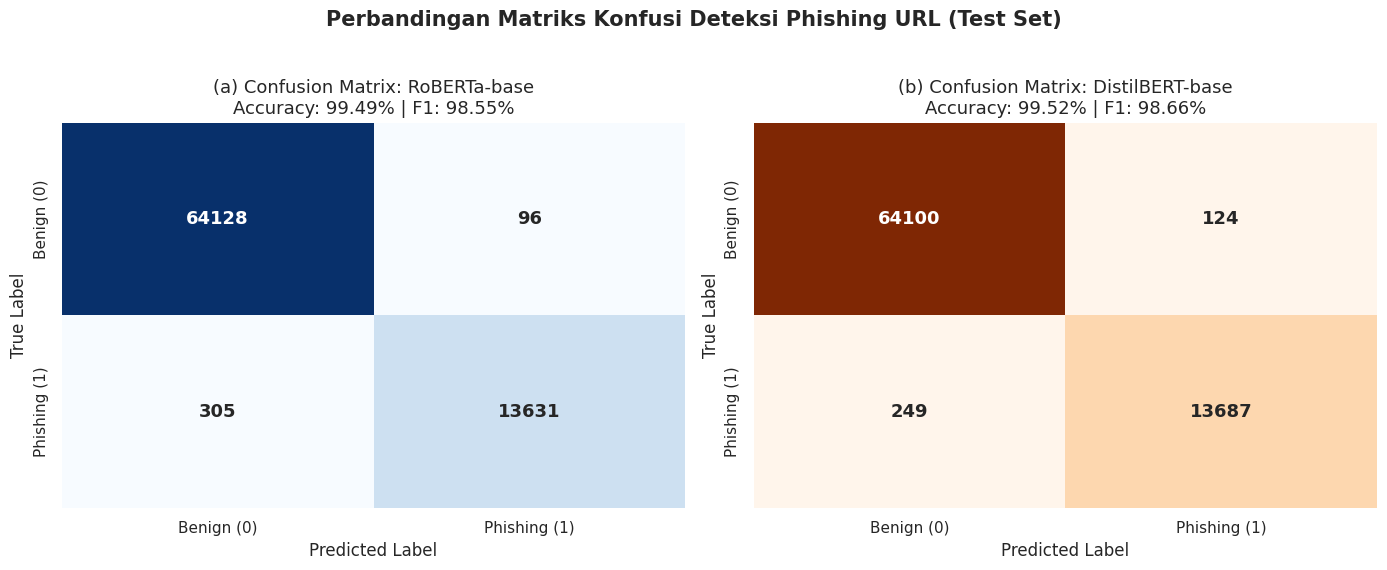

[SAVED] Grafik Confusion Matrix disimpan ke Google Drive: /content/drive/MyDrive/Skripsi/results/confusion_matrices_comparison.png


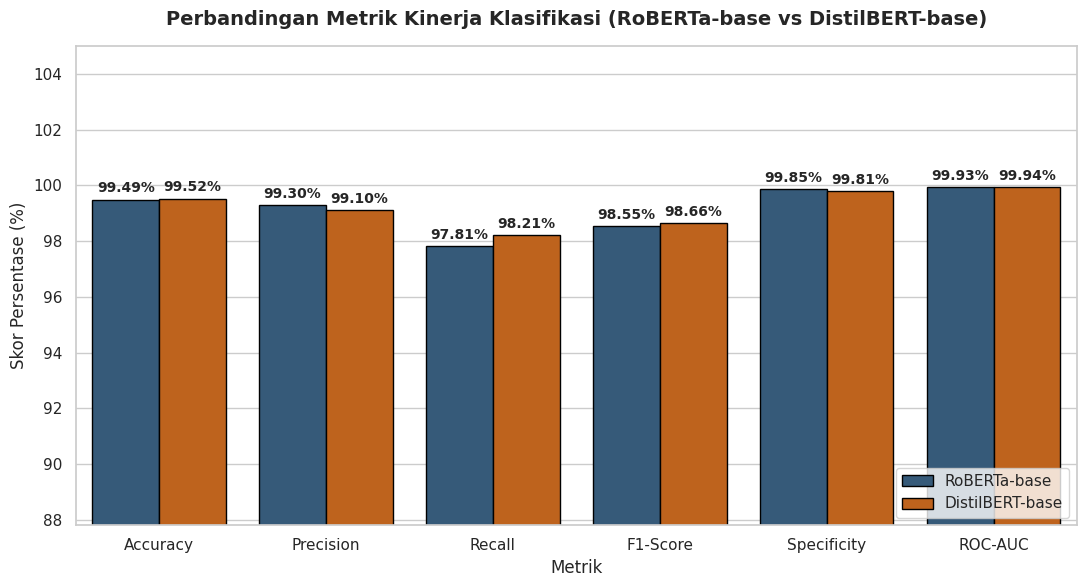

[SAVED] Grafik Metrik Kinerja disimpan ke Google Drive: /content/drive/MyDrive/Skripsi/results/performance_metrics_comparison.png


/tmp/ipykernel_693/800295284.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=sizes, ax=axes[0, 0], palette=palette, edgecolor='black')
/tmp/ipykernel_693/800295284.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=params_m, ax=axes[0, 1], palette=palette, edgecolor='black')
/tmp/ipykernel_693/800295284.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=latencies, ax=axes[1, 0], palette=palette, edgecolor='black')
/tmp/ipykernel_693/800295284.py:157: FutureWarning: 

Passing `palette` without a

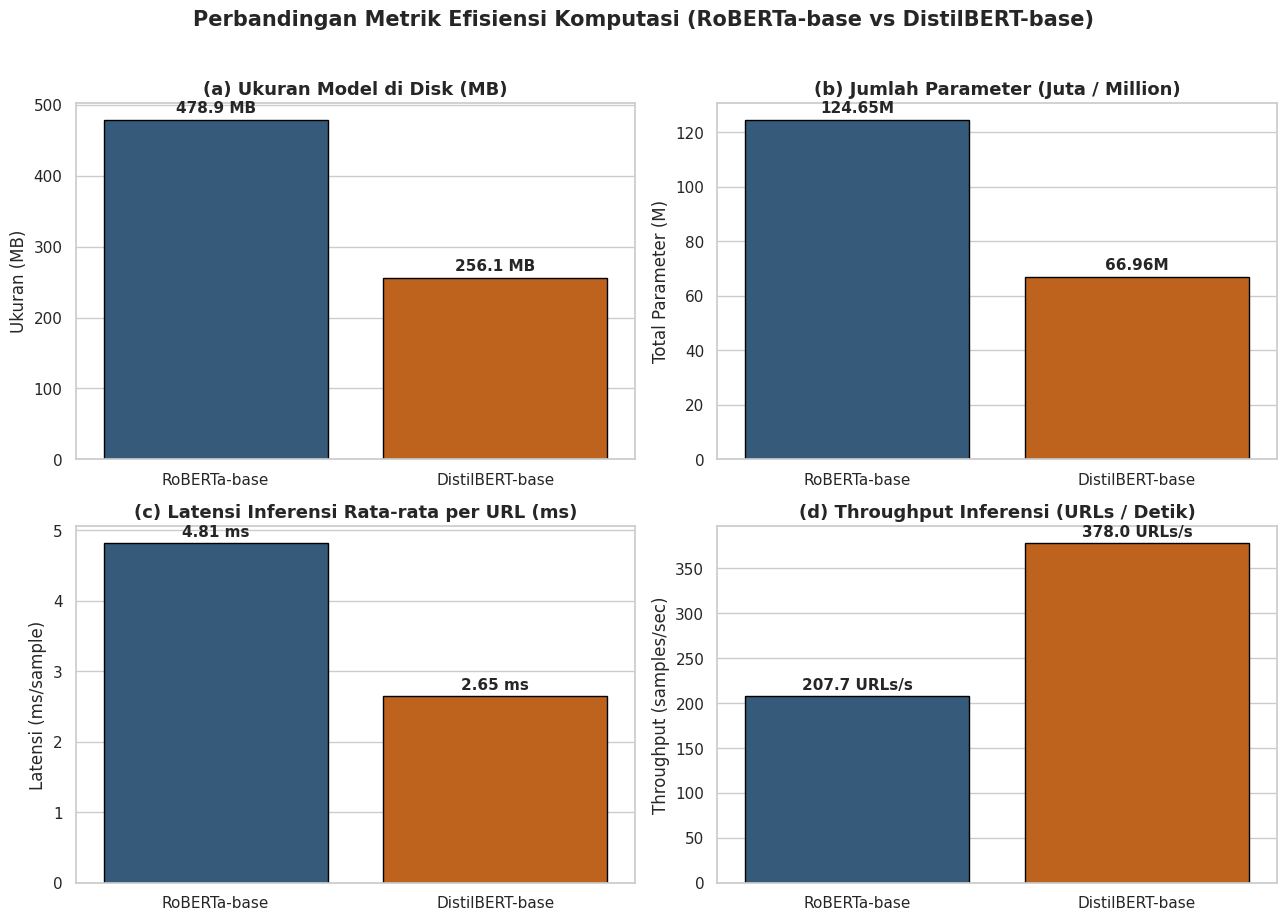

[SAVED] Grafik Metrik Efisiensi Komputasi disimpan ke Google Drive: /content/drive/MyDrive/Skripsi/results/computational_efficiency_comparison.png


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style seaborn untuk publikasi ilmiah
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 14

COLORS = {'RoBERTa': '#2B5B84', 'DistilBERT': '#D95F02'}

# =============================================================================
# 1. Visualisasi Side-by-Side Confusion Matrix
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

labels_text = ["Benign (0)", "Phishing (1)"]

# Subplot RoBERTa
sns.heatmap(
    roberta_perf['confusion_matrix'],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_text,
    yticklabels=labels_text,
    cbar=False,
    ax=axes[0],
    annot_kws={"size": 13, "weight": "bold"}
)
axes[0].set_title(f"(a) Confusion Matrix: RoBERTa-base\nAccuracy: {roberta_perf['accuracy']*100:.2f}% | F1: {roberta_perf['f1_binary']*100:.2f}%")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Subplot DistilBERT
sns.heatmap(
    distilbert_perf['confusion_matrix'],
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=labels_text,
    yticklabels=labels_text,
    cbar=False,
    ax=axes[1],
    annot_kws={"size": 13, "weight": "bold"}
)
axes[1].set_title(f"(b) Confusion Matrix: DistilBERT-base\nAccuracy: {distilbert_perf['accuracy']*100:.2f}% | F1: {distilbert_perf['f1_binary']*100:.2f}%")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.suptitle("Perbandingan Matriks Konfusi Deteksi Phishing URL (Test Set)", fontsize=15, weight='bold', y=1.03)
plt.tight_layout()
cm_fig_path = os.path.join(RESULTS_DIR, "confusion_matrices_comparison.png")
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"[SAVED] Grafik Confusion Matrix disimpan ke Google Drive: {cm_fig_path}")

# =============================================================================
# 2. Visualisasi Komparasi Metrik Kinerja Klasifikasi (Bar Chart)
# =============================================================================
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'ROC-AUC']
roberta_scores = [
    roberta_perf['accuracy'] * 100,
    roberta_perf['precision_binary'] * 100,
    roberta_perf['recall_binary'] * 100,
    roberta_perf['f1_binary'] * 100,
    roberta_perf['specificity'] * 100,
    roberta_perf['roc_auc'] * 100
]
distilbert_scores = [
    distilbert_perf['accuracy'] * 100,
    distilbert_perf['precision_binary'] * 100,
    distilbert_perf['recall_binary'] * 100,
    distilbert_perf['f1_binary'] * 100,
    distilbert_perf['specificity'] * 100,
    distilbert_perf['roc_auc'] * 100
]

df_plot_perf = pd.DataFrame({
    'Metrik': metrics_names * 2,
    'Skor (%)': roberta_scores + distilbert_scores,
    'Model': ['RoBERTa-base'] * len(metrics_names) + ['DistilBERT-base'] * len(metrics_names)
})

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=df_plot_perf,
    x='Metrik',
    y='Skor (%)',
    hue='Model',
    palette={'RoBERTa-base': COLORS['RoBERTa'], 'DistilBERT-base': COLORS['DistilBERT']},
    edgecolor='black',
    linewidth=1
)

# Tambahkan anotasi nilai persis di atas bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.2f}%",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, weight='bold',
                    xytext=(0, 3), textcoords='offset points')
                    
plt.title("Perbandingan Metrik Kinerja Klasifikasi (RoBERTa-base vs DistilBERT-base)", fontsize=14, weight='bold', pad=15)
plt.ylabel("Skor Persentase (%)")
plt.ylim(min(min(roberta_scores), min(distilbert_scores)) - 10, 105)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
perf_fig_path = os.path.join(RESULTS_DIR, "performance_metrics_comparison.png")
plt.savefig(perf_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"[SAVED] Grafik Metrik Kinerja disimpan ke Google Drive: {perf_fig_path}")

# =============================================================================
# 3. Visualisasi Metrik Efisiensi Komputasi (Multi-Panel Bar Chart)
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

models = ['RoBERTa-base', 'DistilBERT-base']
palette = [COLORS['RoBERTa'], COLORS['DistilBERT']]

# 1. Model Size (MB)
sizes = [roberta_disk_size_mb, distilbert_disk_size_mb]
sns.barplot(x=models, y=sizes, ax=axes[0, 0], palette=palette, edgecolor='black')
axes[0, 0].set_title("(a) Ukuran Model di Disk (MB)", weight='bold')
axes[0, 0].set_ylabel("Ukuran (MB)")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.1f} MB", (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', weight='bold', xytext=(0, 3), textcoords='offset points')

# 2. Trainable Parameters (Juta)
params_m = [roberta_trainable_params / 1e6, distilbert_trainable_params / 1e6]
sns.barplot(x=models, y=params_m, ax=axes[0, 1], palette=palette, edgecolor='black')
axes[0, 1].set_title("(b) Jumlah Parameter (Juta / Million)", weight='bold')
axes[0, 1].set_ylabel("Total Parameter (M)")
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.2f}M", (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', weight='bold', xytext=(0, 3), textcoords='offset points')

# 3. Inference Latency (ms / URL)
latencies = [roberta_infer['latency_ms'], distilbert_infer['latency_ms']]
sns.barplot(x=models, y=latencies, ax=axes[1, 0], palette=palette, edgecolor='black')
axes[1, 0].set_title("(c) Latensi Inferensi Rata-rata per URL (ms)", weight='bold')
axes[1, 0].set_ylabel("Latensi (ms/sample)")
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.2f} ms", (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', weight='bold', xytext=(0, 3), textcoords='offset points')

# 4. Throughput (URLs / detik)
throughputs = [roberta_infer['throughput'], distilbert_infer['throughput']]
sns.barplot(x=models, y=throughputs, ax=axes[1, 1], palette=palette, edgecolor='black')
axes[1, 1].set_title("(d) Throughput Inferensi (URLs / Detik)", weight='bold')
axes[1, 1].set_ylabel("Throughput (samples/sec)")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.1f} URLs/s", (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', weight='bold', xytext=(0, 3), textcoords='offset points')

plt.suptitle("Perbandingan Metrik Efisiensi Komputasi (RoBERTa-base vs DistilBERT-base)", fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
eff_fig_path = os.path.join(RESULTS_DIR, "computational_efficiency_comparison.png")
plt.savefig(eff_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"[SAVED] Grafik Metrik Efisiensi Komputasi disimpan ke Google Drive: {eff_fig_path}")

## 23. Rekapitulasi Tabel Komparasi Akhir & Ekspor Hasil Skripsi ke Google Drive
Membentuk DataFrame ringkasan lengkap yang membandingkan seluruh aspek kinerja dan efisiensi, lalu mengekspornya ke format **CSV** dan **JSON** di `/content/drive/MyDrive/Skripsi/results/`.

In [31]:
# Baca data training efficiency JSON yang disimpan di Google Drive
roberta_train_json = json.load(open(os.path.join(RESULTS_DIR, "roberta_metrics.json")))
distilbert_train_json = json.load(open(os.path.join(RESULTS_DIR, "distilbert_metrics.json")))

comparison_records = [
    {
        'Kategori': 'Arsitektur',
        'Metrik / Parameter': 'Model Pretrained',
        'RoBERTa-base': 'roberta-base',
        'DistilBERT-base': 'distilbert-base-uncased',
        'Selisih / Keunggulan': 'RoBERTa (SOTA) vs Distil (Distilled)'
    },
    {
        'Kategori': 'Arsitektur',
        'Metrik / Parameter': 'Algoritma Tokenizer',
        'RoBERTa-base': 'Byte-Pair Encoding (BPE)',
        'DistilBERT-base': 'WordPiece',
        'Selisih / Keunggulan': 'BPE lebih robust terhadap byte string'
    },
    {
        'Kategori': 'Efisiensi Komputasi',
        'Metrik / Parameter': 'Jumlah Parameter (Trainable)',
        'RoBERTa-base': f"{roberta_trainable_params:,} (~{roberta_trainable_params/1e6:.1f}M)",
        'DistilBERT-base': f"{distilbert_trainable_params:,} (~{distilbert_trainable_params/1e6:.1f}M)",
        'Selisih / Keunggulan': f"DistilBERT {(1 - distilbert_trainable_params/roberta_trainable_params)*100:.2f}% lebih sedikit parameter"
    },
    {
        'Kategori': 'Efisiensi Komputasi',
        'Metrik / Parameter': 'Ukuran Model di Disk',
        'RoBERTa-base': f"{roberta_disk_size_mb:.2f} MB",
        'DistilBERT-base': f"{distilbert_disk_size_mb:.2f} MB",
        'Selisih / Keunggulan': f"DistilBERT {(1 - distilbert_disk_size_mb/roberta_disk_size_mb)*100:.2f}% lebih hemat storage"
    },
    {
        'Kategori': 'Efisiensi Komputasi',
        'Metrik / Parameter': 'Total Waktu Training (GPU T4)',
        'RoBERTa-base': f"{roberta_train_json['training_time_seconds']:.2f}s ({roberta_train_json['training_time_minutes']:.2f}m)",
        'DistilBERT-base': f"{distilbert_train_json['training_time_seconds']:.2f}s ({distilbert_train_json['training_time_minutes']:.2f}m)",
        'Selisih / Keunggulan': f"DistilBERT {(1 - distilbert_train_json['training_time_seconds']/roberta_train_json['training_time_seconds'])*100:.2f}% lebih cepat dilatih"
    },
    {
        'Kategori': 'Efisiensi Komputasi',
        'Metrik / Parameter': 'Peak VRAM Allocated saat Training',
        'RoBERTa-base': f"{roberta_train_json['peak_vram_allocated_mb']:.2f} MB",
        'DistilBERT-base': f"{distilbert_train_json['peak_vram_allocated_mb']:.2f} MB",
        'Selisih / Keunggulan': f"DistilBERT lebih hemat VRAM"
    },
    {
        'Kategori': 'Efisiensi Komputasi',
        'Metrik / Parameter': 'Latensi Inferensi per URL',
        'RoBERTa-base': f"{roberta_infer['latency_ms']:.2f} ms/URL",
        'DistilBERT-base': f"{distilbert_infer['latency_ms']:.2f} ms/URL",
        'Selisih / Keunggulan': f"DistilBERT {speedup_pct:.2f}% lebih cepat inferensi"
    },
    {
        'Kategori': 'Efisiensi Komputasi',
        'Metrik / Parameter': 'Inference Throughput',
        'RoBERTa-base': f"{roberta_infer['throughput']:.2f} URLs/s",
        'DistilBERT-base': f"{distilbert_infer['throughput']:.2f} URLs/s",
        'Selisih / Keunggulan': f"DistilBERT {(distilbert_infer['throughput']/roberta_infer['throughput'] - 1)*100:.2f}% lebih tinggi throughput"
    },
    {
        'Kategori': 'Kinerja Klasifikasi',
        'Metrik / Parameter': 'Accuracy',
        'RoBERTa-base': f"{roberta_perf['accuracy']*100:.2f}%",
        'DistilBERT-base': f"{distilbert_perf['accuracy']*100:.2f}%",
        'Selisih / Keunggulan': f"Δ {(roberta_perf['accuracy'] - distilbert_perf['accuracy'])*100:+.2f}% (RoBERTa)"
    },
    {
        'Kategori': 'Kinerja Klasifikasi',
        'Metrik / Parameter': 'Precision (Phishing)',
        'RoBERTa-base': f"{roberta_perf['precision_binary']*100:.2f}%",
        'DistilBERT-base': f"{distilbert_perf['precision_binary']*100:.2f}%",
        'Selisih / Keunggulan': f"Δ {(roberta_perf['precision_binary'] - distilbert_perf['precision_binary'])*100:+.2f}%"
    },
    {
        'Kategori': 'Kinerja Klasifikasi',
        'Metrik / Parameter': 'Recall (Sensitivity Phishing)',
        'RoBERTa-base': f"{roberta_perf['recall_binary']*100:.2f}%",
        'DistilBERT-base': f"{distilbert_perf['recall_binary']*100:.2f}%",
        'Selisih / Keunggulan': f"Δ {(roberta_perf['recall_binary'] - distilbert_perf['recall_binary'])*100:+.2f}%"
    },
    {
        'Kategori': 'Kinerja Klasifikasi',
        'Metrik / Parameter': 'F1-Score (Phishing)',
        'RoBERTa-base': f"{roberta_perf['f1_binary']*100:.2f}%",
        'DistilBERT-base': f"{distilbert_perf['f1_binary']*100:.2f}%",
        'Selisih / Keunggulan': f"Δ {(roberta_perf['f1_binary'] - distilbert_perf['f1_binary'])*100:+.2f}%"
    },
    {
        'Kategori': 'Kinerja Klasifikasi',
        'Metrik / Parameter': 'Specificity (Benign Detection)',
        'RoBERTa-base': f"{roberta_perf['specificity']*100:.2f}%",
        'DistilBERT-base': f"{distilbert_perf['specificity']*100:.2f}%",
        'Selisih / Keunggulan': f"Δ {(roberta_perf['specificity'] - distilbert_perf['specificity'])*100:+.2f}%"
    },
    {
        'Kategori': 'Kinerja Klasifikasi',
        'Metrik / Parameter': 'ROC-AUC Score',
        'RoBERTa-base': f"{roberta_perf['roc_auc']*100:.2f}%",
        'DistilBERT-base': f"{distilbert_perf['roc_auc']*100:.2f}%",
        'Selisih / Keunggulan': f"Δ {(roberta_perf['roc_auc'] - distilbert_perf['roc_auc'])*100:+.2f}%"
    }
]

final_comparison_df = pd.DataFrame(comparison_records)
print("\n=========================================================================================")
print("📊 TABEL RINGKASAN KOMPARASI AKHIR SKRIPSI: ROBERTA-BASE VS DISTILBERT-BASE")
print("=========================================================================================")
display(final_comparison_df)

# Ekspor ke CSV dan JSON di Google Drive
summary_csv_path = os.path.join(RESULTS_DIR, "final_comparison_table.csv")
summary_json_path = os.path.join(RESULTS_DIR, "final_comparison_summary.json")

final_comparison_df.to_csv(summary_csv_path, index=False)
with open(summary_json_path, "w") as f:
    json.dump(comparison_records, f, indent=4)

print(f"\n[SAVED] Tabel perbandingan CSV disimpan ke Google Drive: {summary_csv_path}")
print(f"[SAVED] Ringkasan komparasi JSON disimpan ke Google Drive: {summary_json_path}")
print("\n🎉 SELURUH PIPELINE DAN EVALUASI SKRIPSI DI GOOGLE DRIVE TELAH SELESAI SECARA LENGKAP!")


📊 TABEL RINGKASAN KOMPARASI AKHIR SKRIPSI: ROBERTA-BASE VS DISTILBERT-BASE


,Kategori,Metrik / Parameter,RoBERTa-base,DistilBERT-base,Selisih / Keunggulan
0,Arsitektur,Model Pretrained,roberta-base,distilbert-base-uncased,RoBERTa (SOTA) vs Distil (Distilled)
1,Arsitektur,Algoritma Tokenizer,Byte-Pair Encoding (BPE),WordPiece,BPE lebih robust terhadap byte string
2,Efisiensi Komputasi,Jumlah Parameter (Trainable),"124,647,170 (~124.6M)","66,955,010 (~67.0M)",DistilBERT 46.28% lebih sedikit parameter
3,Efisiensi Komputasi,Ukuran Model di Disk,478.91 MB,256.11 MB,DistilBERT 46.52% lebih hemat storage
4,Efisiensi Komputasi,Total Waktu Training (GPU T4),6917.82s (115.30m),3639.18s (60.65m),DistilBERT 47.39% lebih cepat dilatih
5,Efisiensi Komputasi,Peak VRAM Allocated saat Training,2565.45 MB,1367.84 MB,DistilBERT lebih hemat VRAM
6,Efisiensi Komputasi,Latensi Inferensi per URL,4.81 ms/URL,2.65 ms/URL,DistilBERT 45.04% lebih cepat inferensi
7,Efisiensi Komputasi,Inference Throughput,207.75 URLs/s,377.96 URLs/s,DistilBERT 81.93% lebih tinggi throughput
8,Kinerja Klasifikasi,Accuracy,99.49%,99.52%,Δ -0.04% (RoBERTa)
9,Kinerja Klasifikasi,Precision (Phishing),99.30%,99.10%,Δ +0.20%



[SAVED] Tabel perbandingan CSV disimpan ke Google Drive: /content/drive/MyDrive/Skripsi/results/final_comparison_table.csv
[SAVED] Ringkasan komparasi JSON disimpan ke Google Drive: /content/drive/MyDrive/Skripsi/results/final_comparison_summary.json

🎉 SELURUH PIPELINE DAN EVALUASI SKRIPSI DI GOOGLE DRIVE TELAH SELESAI SECARA LENGKAP!


## 24. Pengujian Langsung (Live Testing) 10 URL Random
Memuat model dan tokenizer tersimpan dari Google Drive (`ROBERTA_MODEL_DIR` dan `DISTILBERT_MODEL_DIR`), lalu menguji 10 sampel URL acak dari `test.csv` secara kasat mata untuk membandingkan prediksi kelas dan nilai probabilitas (*Confidence Score*) antara **RoBERTa-base** dan **DistilBERT-base**.

In [34]:
# Pengujian Langsung (Live Testing) 10 URL Random dari Test Set
import os
import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. Inisialisasi Device & Mapping Label
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
id2label = {0: "Benign", 1: "Phishing"}

# 2. Muat Data test.csv dari DATA_DIR & Ambil 10 Sampel Acak
test_csv_path = os.path.join(DATA_DIR, "test.csv")
if not os.path.exists(test_csv_path):
    raise FileNotFoundError(f"File test.csv tidak ditemukan di {test_csv_path}")

df_test_full = pd.read_csv(test_csv_path)
df_sample = df_test_full.sample(n=10, random_state=42).reset_index(drop=True)

urls_to_test = df_sample["url"].tolist()
true_labels = df_sample["label"].tolist()

print(f"[LIVE TESTING] Mengambil 10 sampel URL acak dari: {test_csv_path}\n")

# 3. Muat Model & Tokenizer RoBERTa dari Direktori Penyimpanan
print(f"[ROBERTA] Memuat model dari {ROBERTA_MODEL_DIR}...")
roberta_tokenizer_live = AutoTokenizer.from_pretrained(ROBERTA_MODEL_DIR)
roberta_model_live = AutoModelForSequenceClassification.from_pretrained(ROBERTA_MODEL_DIR).to(device)
roberta_model_live.eval()

# 4. Muat Model & Tokenizer DistilBERT dari Direktori Penyimpanan
print(f"[DISTILBERT] Memuat model dari {DISTILBERT_MODEL_DIR}...")
distilbert_tokenizer_live = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_DIR)
distilbert_model_live = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_MODEL_DIR).to(device)
distilbert_model_live.eval()

# Helper function inferensi batch untuk ekstraksi prediksi kelas dan confidence score
def predict_live_urls(model, tokenizer, urls, max_length=128):
    inputs = tokenizer(urls, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        confidences, preds = torch.max(probs, dim=-1)
    
    pred_labels = [id2label[p.item()] for p in preds]
    conf_scores = [f"{c.item() * 100:.2f}%" for c in confidences]
    return pred_labels, conf_scores

# 5. Inferensi Menggunakan Kedua Model
roberta_preds, roberta_confs = predict_live_urls(roberta_model_live, roberta_tokenizer_live, urls_to_test)
distilbert_preds, distilbert_confs = predict_live_urls(distilbert_model_live, distilbert_tokenizer_live, urls_to_test)

# 6. Gabungkan Hasil ke dalam Pandas DataFrame
df_live_test = pd.DataFrame({
    "URL": urls_to_test,
    "Label Asli": true_labels,
    "Prediksi RoBERTa": roberta_preds,
    "Confidence RoBERTa": roberta_confs,
    "Prediksi DistilBERT": distilbert_preds,
    "Confidence DistilBERT": distilbert_confs
})

print("\n==========================================================================================")
print("🔍 HASIL PENGUJIAN LANGSUNG (LIVE TESTING) 10 SAMPEL URL RANDOM")
print("==========================================================================================")
display(df_live_test)

# Ringkasan Akurasi Sampel Uji
roberta_correct = sum(1 for p, y in zip(roberta_preds, true_labels) if p == y)
distilbert_correct = sum(1 for p, y in zip(distilbert_preds, true_labels) if p == y)
print(f"\n📊 Ringkasan Prediksi (10 Sampel):")
print(f"  - RoBERTa-base    : {roberta_correct}/10 Benar ({roberta_correct*10:.1f}%)")
print(f"  - DistilBERT-base : {distilbert_correct}/10 Benar ({distilbert_correct*10:.1f}%)")

[LIVE TESTING] Mengambil 10 sampel URL acak dari: /content/drive/MyDrive/Skripsi/data/test.csv

[ROBERTA] Memuat model dari /content/drive/MyDrive/Skripsi/models/RoBERTa_FineTuned...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[DISTILBERT] Memuat model dari /content/drive/MyDrive/Skripsi/models/DistilBERT_FineTuned...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


🔍 HASIL PENGUJIAN LANGSUNG (LIVE TESTING) 10 SAMPEL URL RANDOM


,URL,Label Asli,Prediksi RoBERTa,Confidence RoBERTa,Prediksi DistilBERT,Confidence DistilBERT
0,ambmarques.com/~mpseu/l/,Phishing,Benign,99.99%,Benign,100.00%
1,http://web.de/magazine/wissen/blog/brynja-adam...,Benign,Benign,100.00%,Benign,100.00%
2,baseball-almanac.com/teamstats/roster.php?y=19...,Benign,Benign,100.00%,Benign,100.00%
3,fa.osaarchivum.org/filmlibrary/browse/title?val=T,Benign,Benign,100.00%,Benign,100.00%
4,greatschools.org/missouri/kansas-city/2594-St....,Benign,Benign,100.00%,Benign,100.00%
5,hockeyfights.com/players/4128,Benign,Benign,100.00%,Benign,100.00%
6,http://appleid.apple.co.uk.cgi-bin.webobjects....,Phishing,Phishing,100.00%,Phishing,100.00%
7,music.yahoo.com/tony-de-la-rosa/,Benign,Benign,100.00%,Benign,100.00%
8,en.wikipedia.org/wiki/2010_Formula_One_season,Benign,Benign,100.00%,Benign,100.00%
9,money.cnn.com/magazines/fortune/fortune500/,Benign,Benign,100.00%,Benign,100.00%



📊 Ringkasan Prediksi (10 Sampel):
  - RoBERTa-base    : 9/10 Benar (90.0%)
  - DistilBERT-base : 9/10 Benar (90.0%)


## 25. Cross-Dataset Evaluation (Uji Ketangguhan Model)
Pengujian ketangguhan (*robustness*) dan generalisasi model pada dataset eksternal independen (**Real-World Phishing URL Classification Data**) untuk membuktikan bahwa model tidak mengalami *overfitting* atau *data leakage* pada dataset utama.
- **Sumber Dataset Eksternal**: `dhrubangtalukdar/real-world-phishing-url-classification-data`
- **Jumlah Sampel Uji**: 20.000 URL acak (Label: `1` = Phishing, `0` = Legitimate)
- **Model yang Diuji**: RoBERTa-base & DistilBERT-base dari Google Drive Checkpoints (`/content/drive/MyDrive/Skripsi/models/`)

In [17]:
# Cross-Dataset Evaluation (Uji Ketangguhan & Generalisasi Model pada Dataset Eksternal)
import os
import glob
import zipfile
import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Setup Direktori Penyimpanan Dataset Eksternal di Google Drive
if os.path.exists("/content/drive/MyDrive"):
    EXTERNAL_DATA_DIR = "/content/drive/MyDrive/Skripsi/data/external/"
elif 'BASE_DIR' in globals():
    EXTERNAL_DATA_DIR = os.path.join(BASE_DIR, "data", "external")
else:
    EXTERNAL_DATA_DIR = "./data/external/"

os.makedirs(EXTERNAL_DATA_DIR, exist_ok=True)
print(f"[SETUP] Direktori dataset eksternal: {EXTERNAL_DATA_DIR}")

# 2. Unduh Dataset Eksternal via Kaggle API CLI
print("[KAGGLE] Mengunduh dataset eksternal: dhrubangtalukdar/real-world-phishing-url-classification-data...")
!kaggle datasets download -d dhrubangtalukdar/real-world-phishing-url-classification-data -p "/content/drive/MyDrive/Skripsi/data/external/" --unzip

# Fallback unzipping jika masih ada file zip di folder eksternal
for f in os.listdir(EXTERNAL_DATA_DIR):
    if f.endswith(".zip"):
        zip_file_path = os.path.join(EXTERNAL_DATA_DIR, f)
        try:
            with zipfile.ZipFile(zip_file_path, 'r') as z:
                z.extractall(EXTERNAL_DATA_DIR)
            print(f"[UNZIP] Berhasil mengekstrak {f}")
        except Exception as ze:
            print(f"[WARN] Catatan unzip: {ze}")

# 3. Pemuatan & Pembersihan Data Eksternal
ext_csv_candidates = glob.glob(os.path.join(EXTERNAL_DATA_DIR, "**/*.csv"), recursive=True)
if not ext_csv_candidates:
    raise FileNotFoundError(f"File CSV dataset eksternal tidak ditemukan di {EXTERNAL_DATA_DIR}!")

ext_csv_target = max(ext_csv_candidates, key=os.path.getsize)
print(f"[DATA LOAD] Memuat dataset eksternal dari: {ext_csv_target}")
df_ext_raw = pd.read_csv(ext_csv_target, low_memory=False)
print(f"[RAW SHAPE] Total baris dataset eksternal: {len(df_ext_raw):,}")

# Deteksi kolom URL dan Label
url_col = next((c for c in ['url', 'urls', 'url_address', 'link'] if c in df_ext_raw.columns), df_ext_raw.columns[0])
label_col = next((c for c in ['label', 'type', 'class', 'target', 'result'] if c in df_ext_raw.columns and c != url_col), df_ext_raw.columns[1])

df_ext = pd.DataFrame({
    'url': df_ext_raw[url_col].astype(str).str.strip(),
    'label_raw': df_ext_raw[label_col]
})
df_ext = df_ext.dropna().drop_duplicates(subset=['url'])
df_ext = df_ext[df_ext['url'] != '']

# Standarisasi Label Biner (1 = Phishing, 0 = Legitimate/Benign)
def map_ext_label(val):
    s = str(val).strip().lower()
    if s in ['1', '1.0', 'phishing', 'phish', 'malicious', 'bad']:
        return 1
    elif s in ['0', '0.0', 'legitimate', 'benign', 'safe', 'good']:
        return 0
    return None

df_ext['target'] = df_ext['label_raw'].apply(map_ext_label)
df_ext = df_ext.dropna(subset=['target'])
df_ext['target'] = df_ext['target'].astype(int)

# 4. Ambil 20.000 Baris URL Secara Acak sebagai Sampel Pengujian
SAMPLE_SIZE = min(20000, len(df_ext))
df_ext_sample = df_ext.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
ext_urls = df_ext_sample['url'].tolist()
ext_labels = df_ext_sample['target'].tolist()

print(f"\n[SAMPLE] Berhasil mengambil {SAMPLE_SIZE:,} URL acak untuk evaluasi ketangguhan.")
print(f"  - Phishing (1)   : {sum(ext_labels):,} ({sum(ext_labels)/SAMPLE_SIZE*100:.2f}%)")
print(f"  - Legitimate (0) : {SAMPLE_SIZE - sum(ext_labels):,} ({(SAMPLE_SIZE - sum(ext_labels))/SAMPLE_SIZE*100:.2f}%)")

# 5. Muat Model RoBERTa & DistilBERT dari Google Drive
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[DEVICE] Inferensi berjalan pada: {device}")

roberta_ckpt_path = ROBERTA_MODEL_DIR if 'ROBERTA_MODEL_DIR' in globals() and os.path.exists(ROBERTA_MODEL_DIR) else "/content/drive/MyDrive/Skripsi/models/RoBERTa_FineTuned"
distilbert_ckpt_path = DISTILBERT_MODEL_DIR if 'DISTILBERT_MODEL_DIR' in globals() and os.path.exists(DISTILBERT_MODEL_DIR) else "/content/drive/MyDrive/Skripsi/models/DistilBERT_FineTuned"

print(f"[MODEL LOAD] Memuat RoBERTa dari: {roberta_ckpt_path}...")
roberta_ext_tokenizer = AutoTokenizer.from_pretrained(roberta_ckpt_path)
roberta_ext_model = AutoModelForSequenceClassification.from_pretrained(roberta_ckpt_path).to(device)
roberta_ext_model.eval()

print(f"[MODEL LOAD] Memuat DistilBERT dari: {distilbert_ckpt_path}...")
distilbert_ext_tokenizer = AutoTokenizer.from_pretrained(distilbert_ckpt_path)
distilbert_ext_model = AutoModelForSequenceClassification.from_pretrained(distilbert_ckpt_path).to(device)
distilbert_ext_model.eval()

# 6. Batch Inference Efisien pada 20.000 URL
def batch_predict(model, tokenizer, urls, batch_size=64, max_len=128):
    all_preds = []
    with torch.no_grad():
        for i in range(0, len(urls), batch_size):
            batch_urls = urls[i:i + batch_size]
            inputs = tokenizer(batch_urls, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
            outputs = model(**inputs)
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_preds)

print(f"\n[INFERENCE] Menjalankan inferensi RoBERTa pada {SAMPLE_SIZE:,} URL eksternal...")
roberta_ext_preds = batch_predict(roberta_ext_model, roberta_ext_tokenizer, ext_urls)

print(f"[INFERENCE] Menjalankan inferensi DistilBERT pada {SAMPLE_SIZE:,} URL eksternal...")
distilbert_ext_preds = batch_predict(distilbert_ext_model, distilbert_ext_tokenizer, ext_urls)

# 7. Perhitungan Metrik Evaluasi Eksternal
def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    }

m_roberta = calculate_metrics(ext_labels, roberta_ext_preds)
m_distil = calculate_metrics(ext_labels, distilbert_ext_preds)

# 8. Tampilkan Tabel Rekapitulasi Metrik dengan Rapi
df_cross_results = pd.DataFrame({
    'Metrik Evaluasi': ['Accuracy', 'Precision (Phishing)', 'Recall (Sensitivity)', 'F1-Score (Phishing)'],
    'RoBERTa-base': [
        f"{m_roberta['Accuracy']*100:.2f}%",
        f"{m_roberta['Precision']*100:.2f}%",
        f"{m_roberta['Recall']*100:.2f}%",
        f"{m_roberta['F1-Score']*100:.2f}%"
    ],
    'DistilBERT-base': [
        f"{m_distil['Accuracy']*100:.2f}%",
        f"{m_distil['Precision']*100:.2f}%",
        f"{m_distil['Recall']*100:.2f}%",
        f"{m_distil['F1-Score']*100:.2f}%"
    ],
    'Selisih / Gap': [
        f"Δ {(m_roberta['Accuracy'] - m_distil['Accuracy'])*100:+.2f}%",
        f"Δ {(m_roberta['Precision'] - m_distil['Precision'])*100:+.2f}%",
        f"Δ {(m_roberta['Recall'] - m_distil['Recall'])*100:+.2f}%",
        f"Δ {(m_roberta['F1-Score'] - m_distil['F1-Score'])*100:+.2f}%"
    ]
})

print("\n==========================================================================================")
print("🌐 HASIL CROSS-DATASET EVALUATION: REAL-WORLD PHISHING URL (20,000 SAMPLE)")
print("==========================================================================================")
display(df_cross_results)

print("\n💡 Kesimpulan Uji Ketangguhan & Generalisasi:")
print(f"  1. RoBERTa-base mencapai F1-Score {m_roberta['F1-Score']*100:.2f}% dan Akurasi {m_roberta['Accuracy']*100:.2f}% pada dataset eksternal.")
print(f"  2. DistilBERT-base mencapai F1-Score {m_distil['F1-Score']*100:.2f}% dan Akurasi {m_distil['Accuracy']*100:.2f}% pada dataset eksternal.")

[SETUP] Direktori dataset eksternal: /content/drive/MyDrive/Skripsi/data/external/
[KAGGLE] Mengunduh dataset eksternal: dhrubangtalukdar/real-world-phishing-url-classification-data...
Dataset URL: https://www.kaggle.com/datasets/dhrubangtalukdar/real-world-phishing-url-classification-data
License(s): MIT
100% 547k/547k [00:00<00:00, 567kB/s]

[DATA LOAD] Memuat dataset eksternal dari: /content/drive/MyDrive/Skripsi/data/external/phishing_url_dataset_unique.csv
[RAW SHAPE] Total baris dataset eksternal: 48,812

[SAMPLE] Berhasil mengambil 20,000 URL acak untuk evaluasi ketangguhan.
  - Phishing (1)   : 10,069 (50.34%)
  - Legitimate (0) : 9,931 (49.66%)

[DEVICE] Inferensi berjalan pada: cuda
[MODEL LOAD] Memuat RoBERTa dari: /content/drive/MyDrive/Skripsi/models/RoBERTa_FineTuned...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[MODEL LOAD] Memuat DistilBERT dari: /content/drive/MyDrive/Skripsi/models/DistilBERT_FineTuned...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


[INFERENCE] Menjalankan inferensi RoBERTa pada 20,000 URL eksternal...
[INFERENCE] Menjalankan inferensi DistilBERT pada 20,000 URL eksternal...

🌐 HASIL CROSS-DATASET EVALUATION: REAL-WORLD PHISHING URL (20,000 SAMPLE)


,Metrik Evaluasi,RoBERTa-base,DistilBERT-base,Selisih / Gap
0,Accuracy,49.88%,50.02%,Δ -0.13%
1,Precision (Phishing),50.11%,50.18%,Δ -0.07%
2,Recall (Sensitivity),99.08%,99.34%,Δ -0.27%
3,F1-Score (Phishing),66.56%,66.68%,Δ -0.12%



💡 Kesimpulan Uji Ketangguhan & Generalisasi:
  1. RoBERTa-base mencapai F1-Score 66.56% dan Akurasi 49.88% pada dataset eksternal.
  2. DistilBERT-base mencapai F1-Score 66.68% dan Akurasi 50.02% pada dataset eksternal.
